# V3 10-Student Problem vs KC Matrices

Problem × KC gap heatmaps for Human A, Human B, and LLM V3 across all 10 students.
Mirrors the exp12 visualization style — each rater side-by-side per student.

In [1]:
import json
from pathlib import Path

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 140

ROOT = Path.cwd()
if not (ROOT / 'results').exists() and (ROOT.parent / 'results').exists():
    ROOT = ROOT.parent

HUMAN_A_FILES = sorted((ROOT / 'dataset/Rater_KC_Tags/Rated_KC_V3').glob('kc_annotations_Pranay Ghuge_*.json'))
HUMAN_B_FILES = sorted((ROOT / 'dataset/Rater_KC_Tags/Rated_KC_V3').glob('kc_annotations_Arundhati Das_*.json'))
LLM_V3_FILES  = sorted((ROOT / 'results/human_validation/llm_v3_10students').glob('llm_v3_annotations_*.json'))

FIG_DIR = ROOT / 'results/human_validation/exp19_visualizations'
FIG_DIR.mkdir(parents=True, exist_ok=True)

KC_COLUMNS = [
    'If/Else', 'NestedIf', 'While', 'For', 'NestedFor',
    'Math+-*/', 'Math%', 'LogicAndNotOr', 'LogicCompareNum', 'LogicBoolean',
    'StringFormat', 'StringConcat', 'StringIndex', 'StringLen',
    'StringEqual', 'CharEqual', 'ArrayIndex', 'DefFunction',
]

In [2]:
def load_annotations(filepath: Path):
    with filepath.open('r', encoding='utf-8') as f:
        data = json.load(f)
    student_id = str(data.get('student_id', data.get('studentId', 'unknown')))
    annotations = {}
    for pid, item in data.get('annotations', {}).items():
        if isinstance(item, dict):
            gaps = item.get('gaps', [])
        elif isinstance(item, list):
            gaps = item
        else:
            gaps = []
        comp_pid = f'{student_id}_{pid}'
        annotations[comp_pid] = {kc for kc in gaps if kc in KC_COLUMNS}
    return student_id, annotations

anns = {'Human A': {}, 'Human B': {}, 'LLM V3': {}}

for fp in HUMAN_A_FILES:
    _, ann = load_annotations(fp)
    anns['Human A'].update(ann)

for fp in HUMAN_B_FILES:
    _, ann = load_annotations(fp)
    anns['Human B'].update(ann)

for fp in LLM_V3_FILES:
    _, ann = load_annotations(fp)
    anns['LLM V3'].update(ann)

students = sorted(
    {pid.split('_')[0] for a in anns.values() for pid in a},
    key=int,
)
print(f'Students: {students}')
print(f'Problems per rater — HA: {len(anns["Human A"])}, HB: {len(anns["Human B"])}, LLM: {len(anns["LLM V3"])}')

Students: ['9948', '10155', '14189', '14352', '14362', '14363', '14374', '14414', '14474', '14499']
Problems per rater — HA: 372, HB: 372, LLM: 372


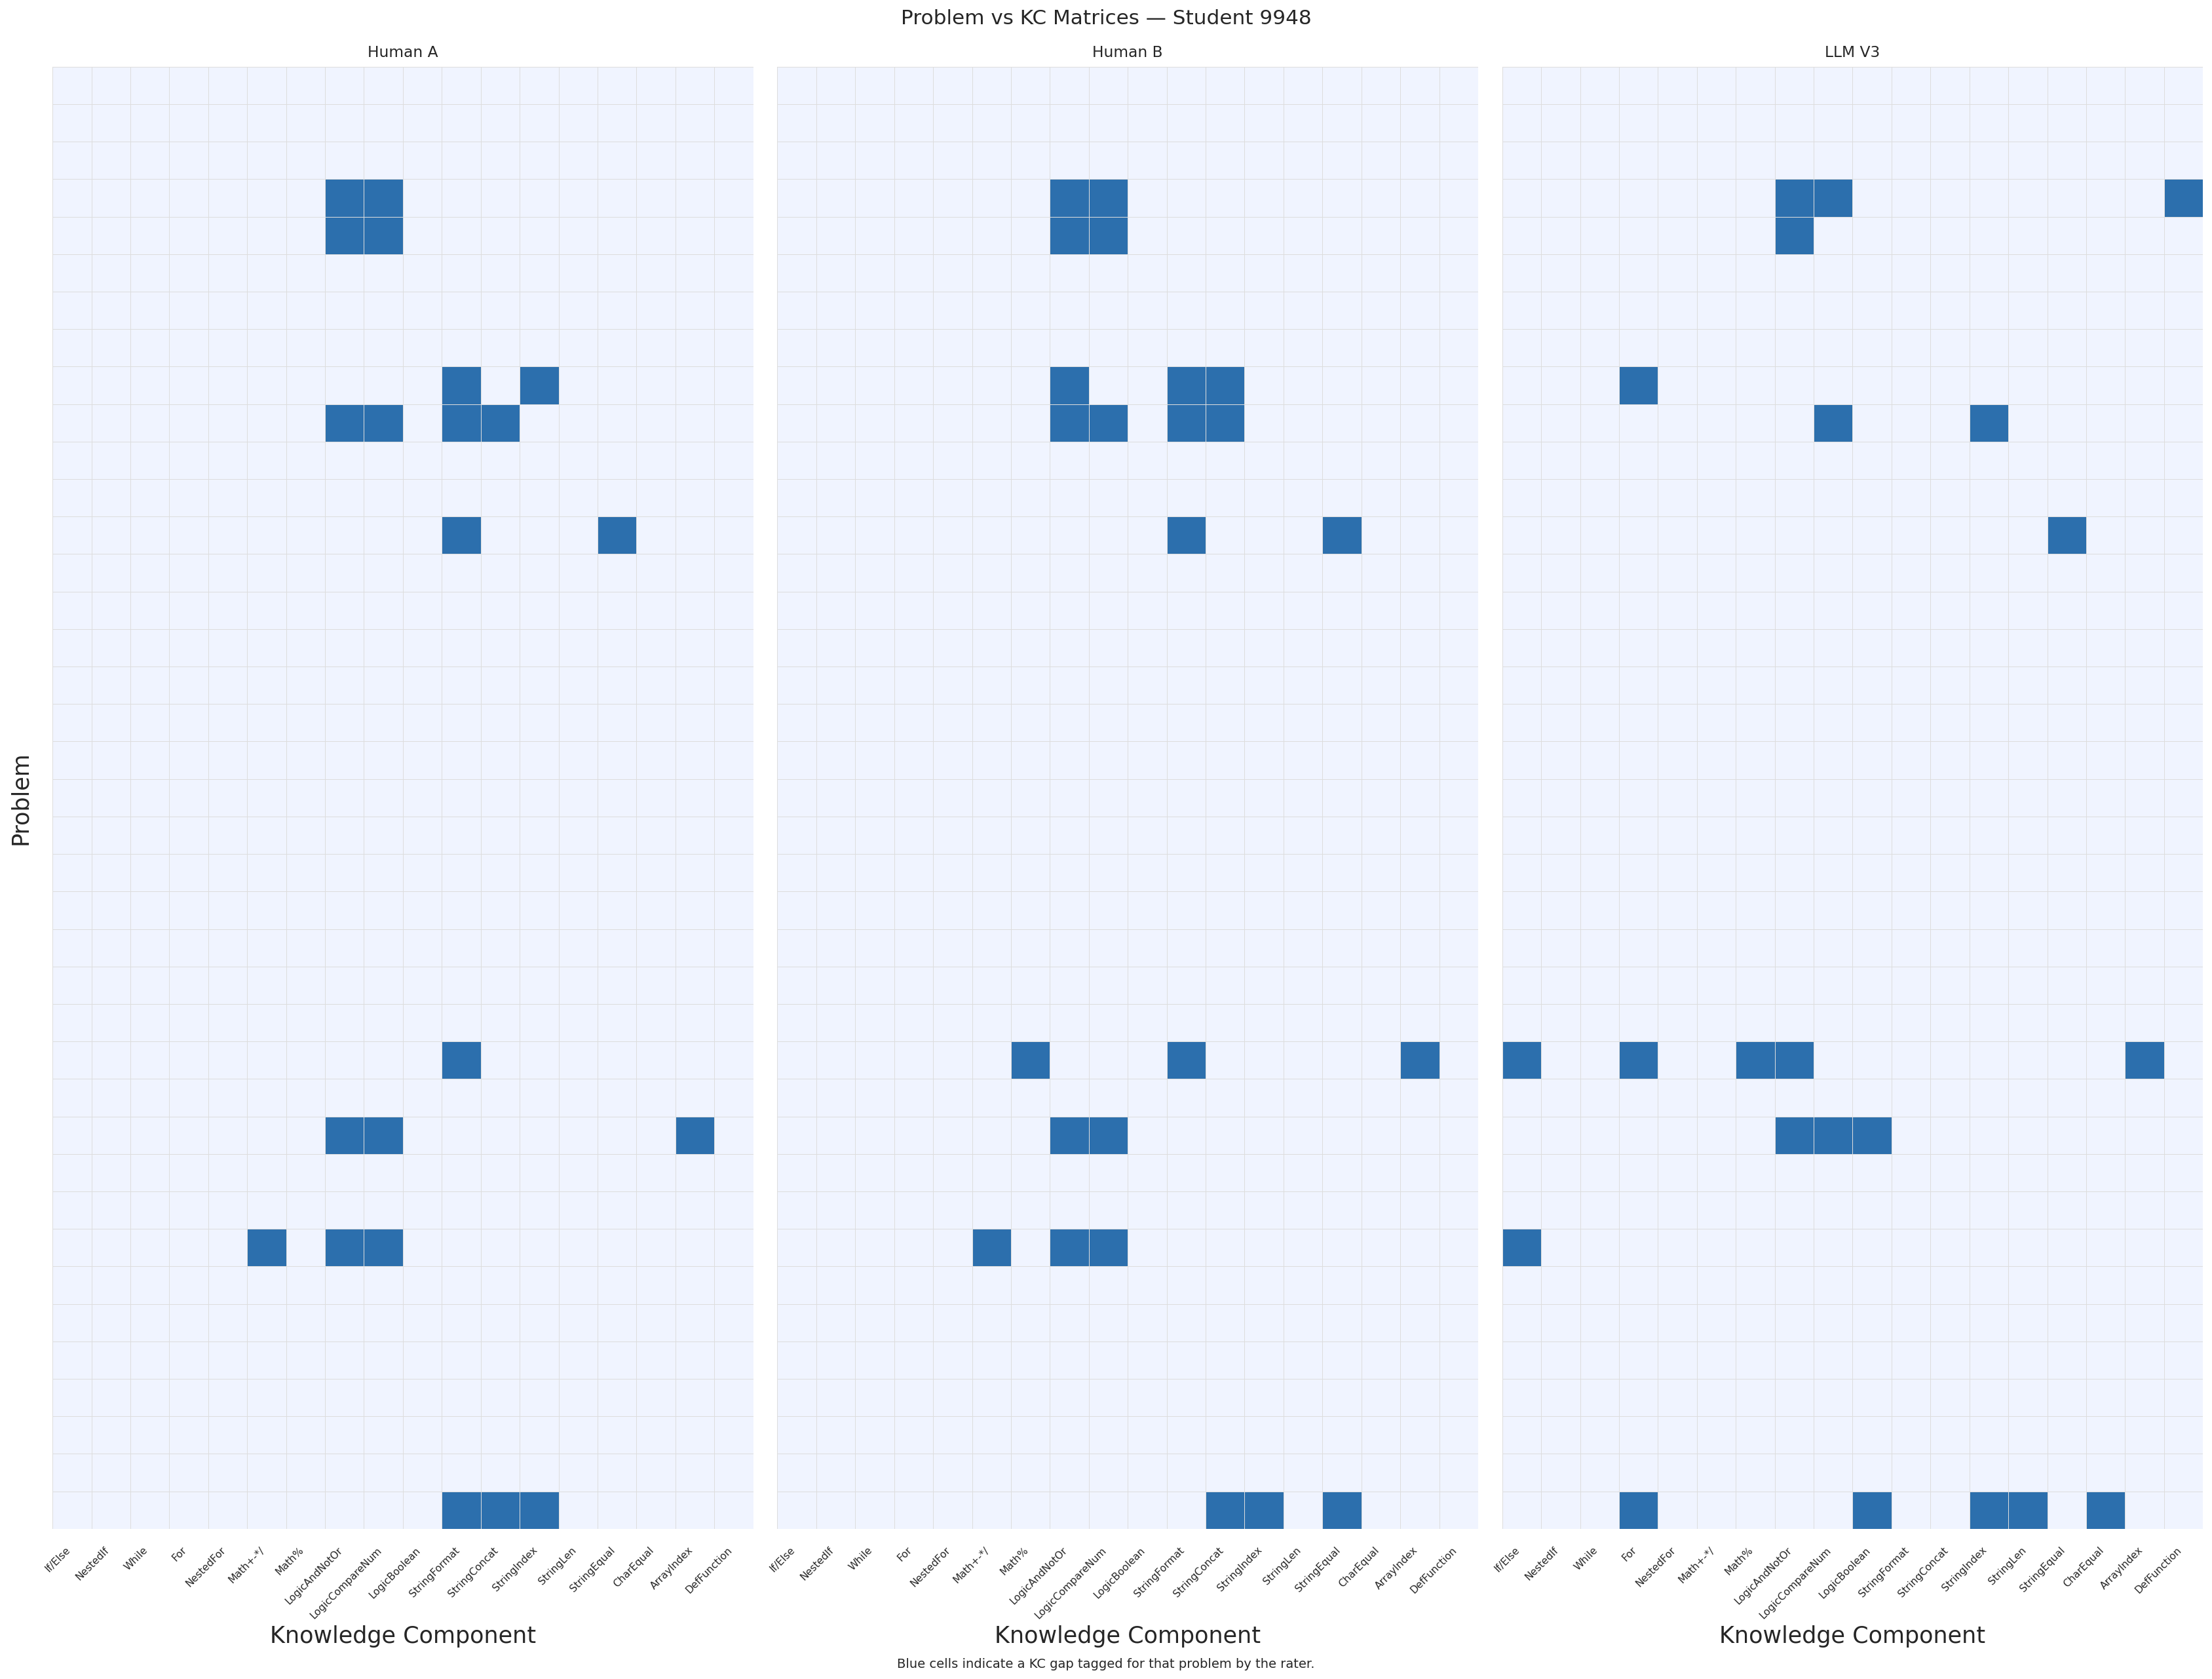

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/problem_kc_matrix_student_9948.png


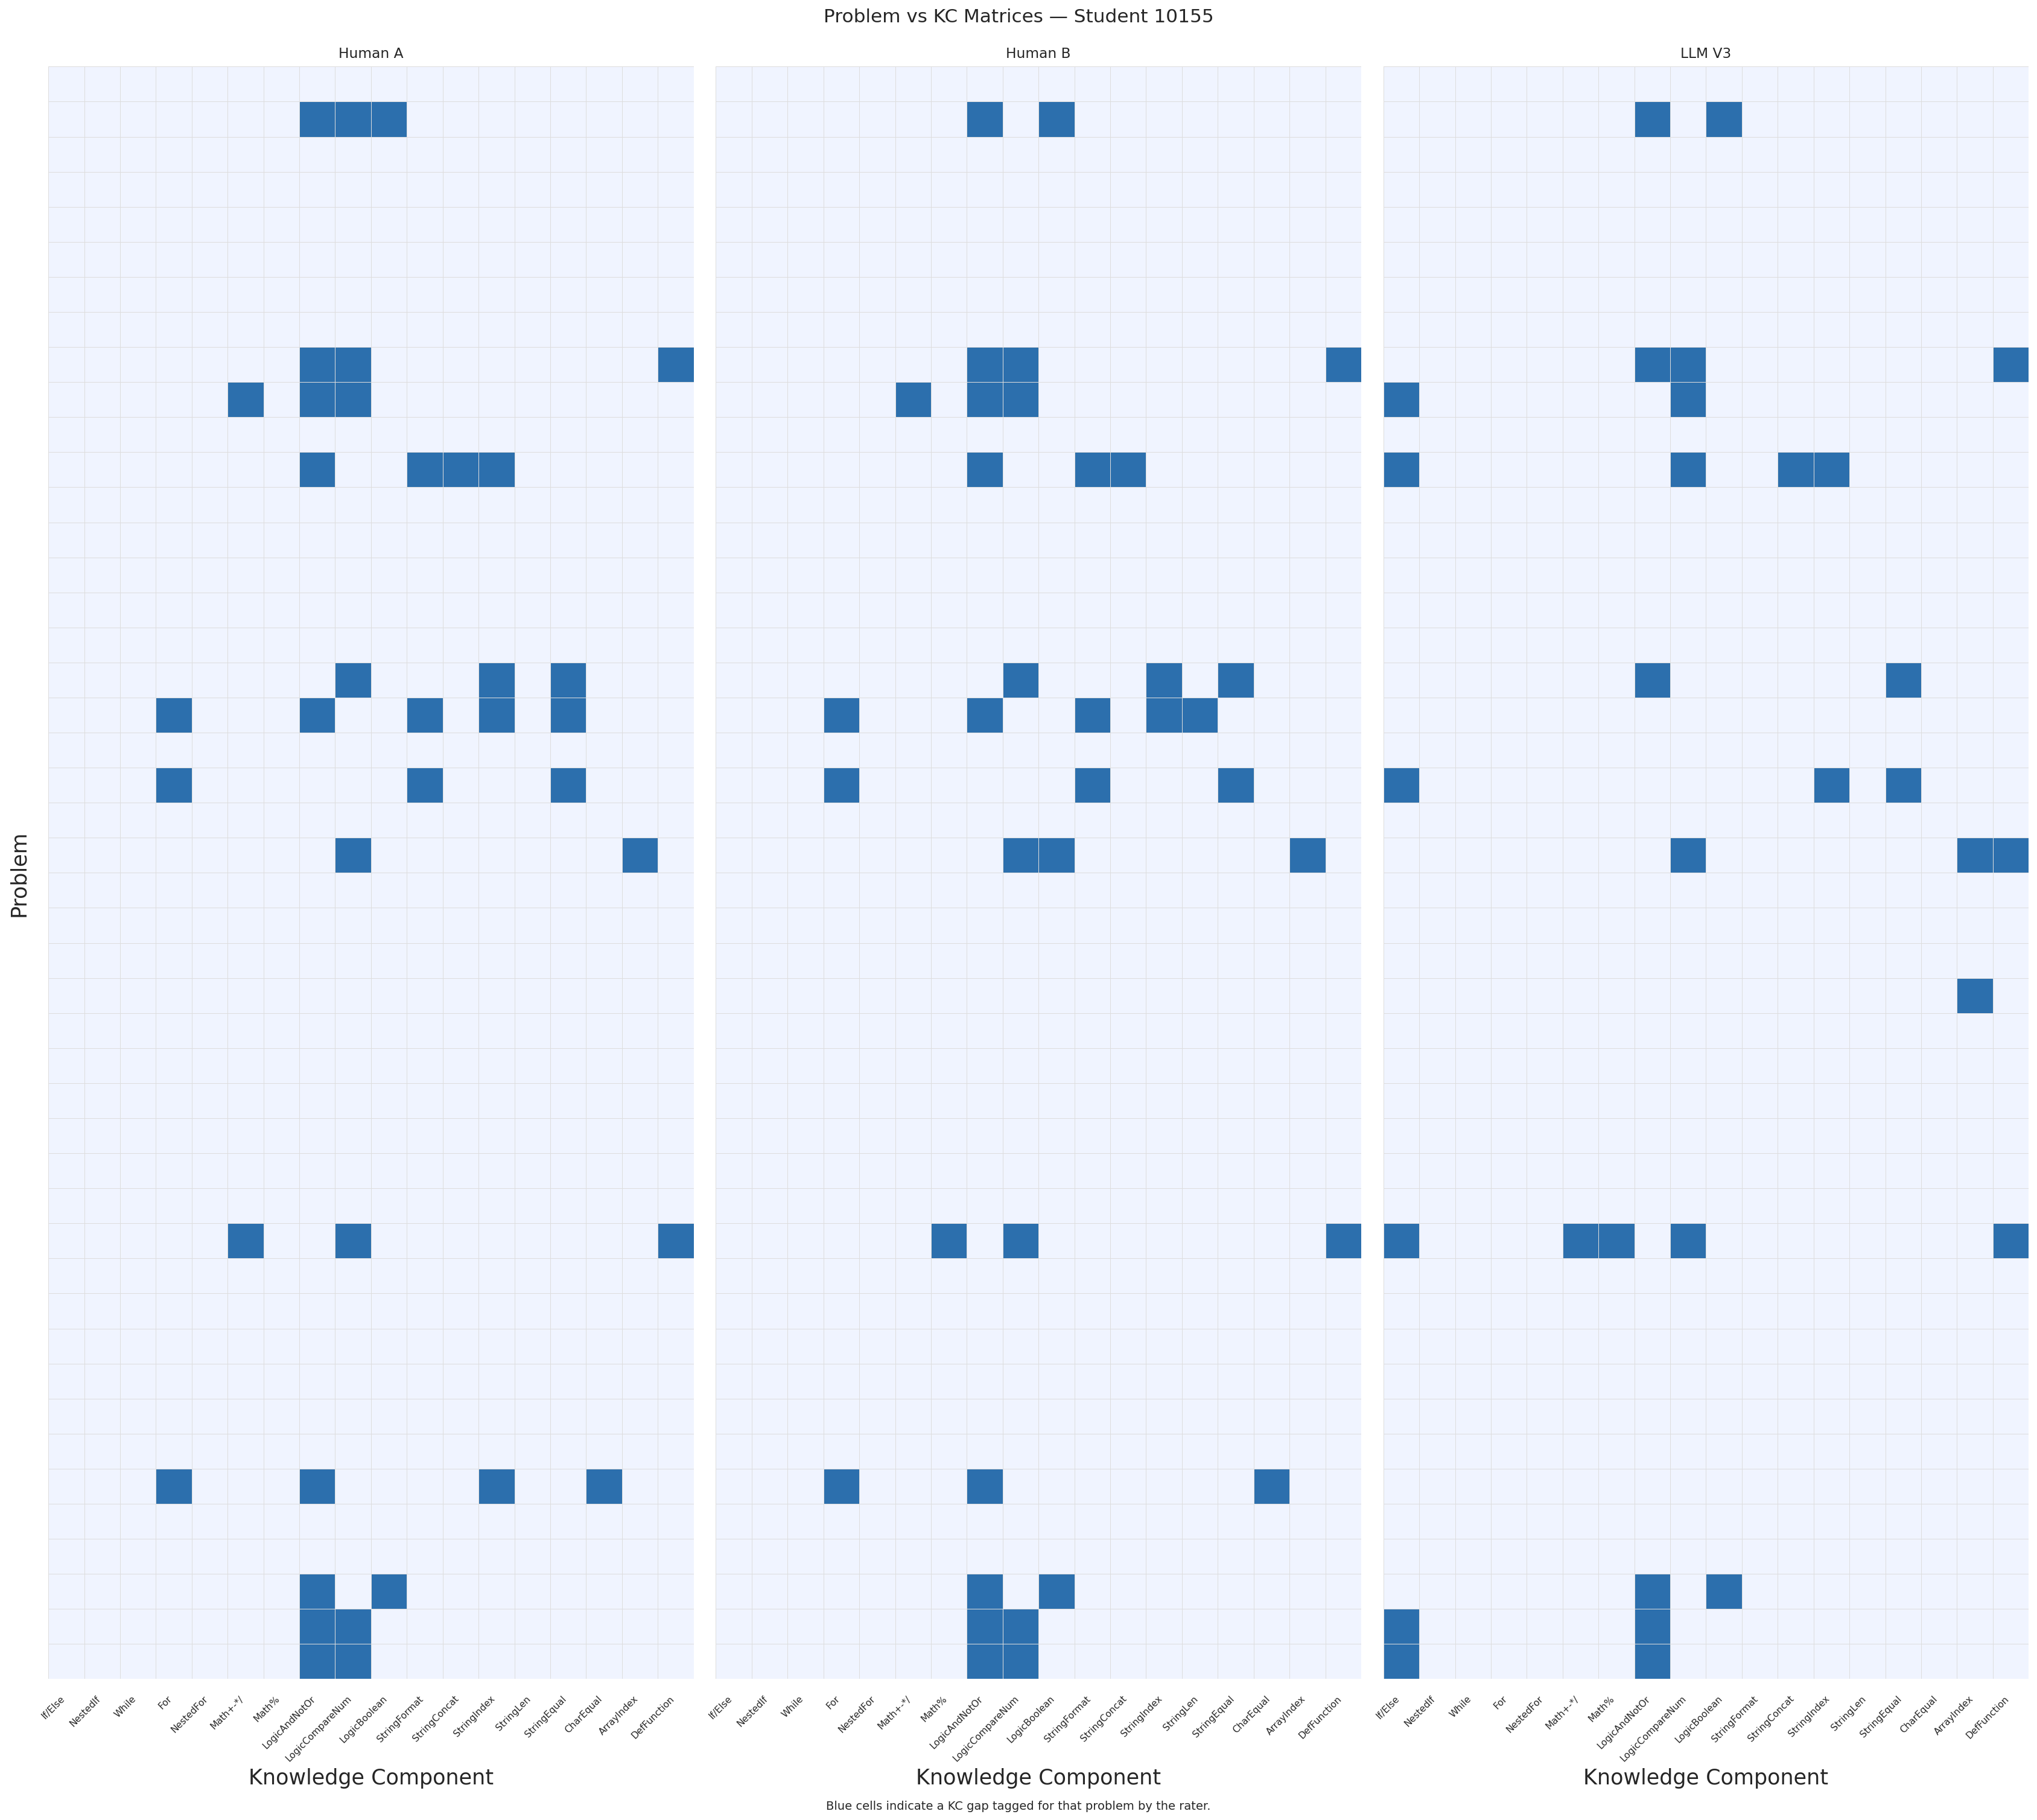

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/problem_kc_matrix_student_10155.png


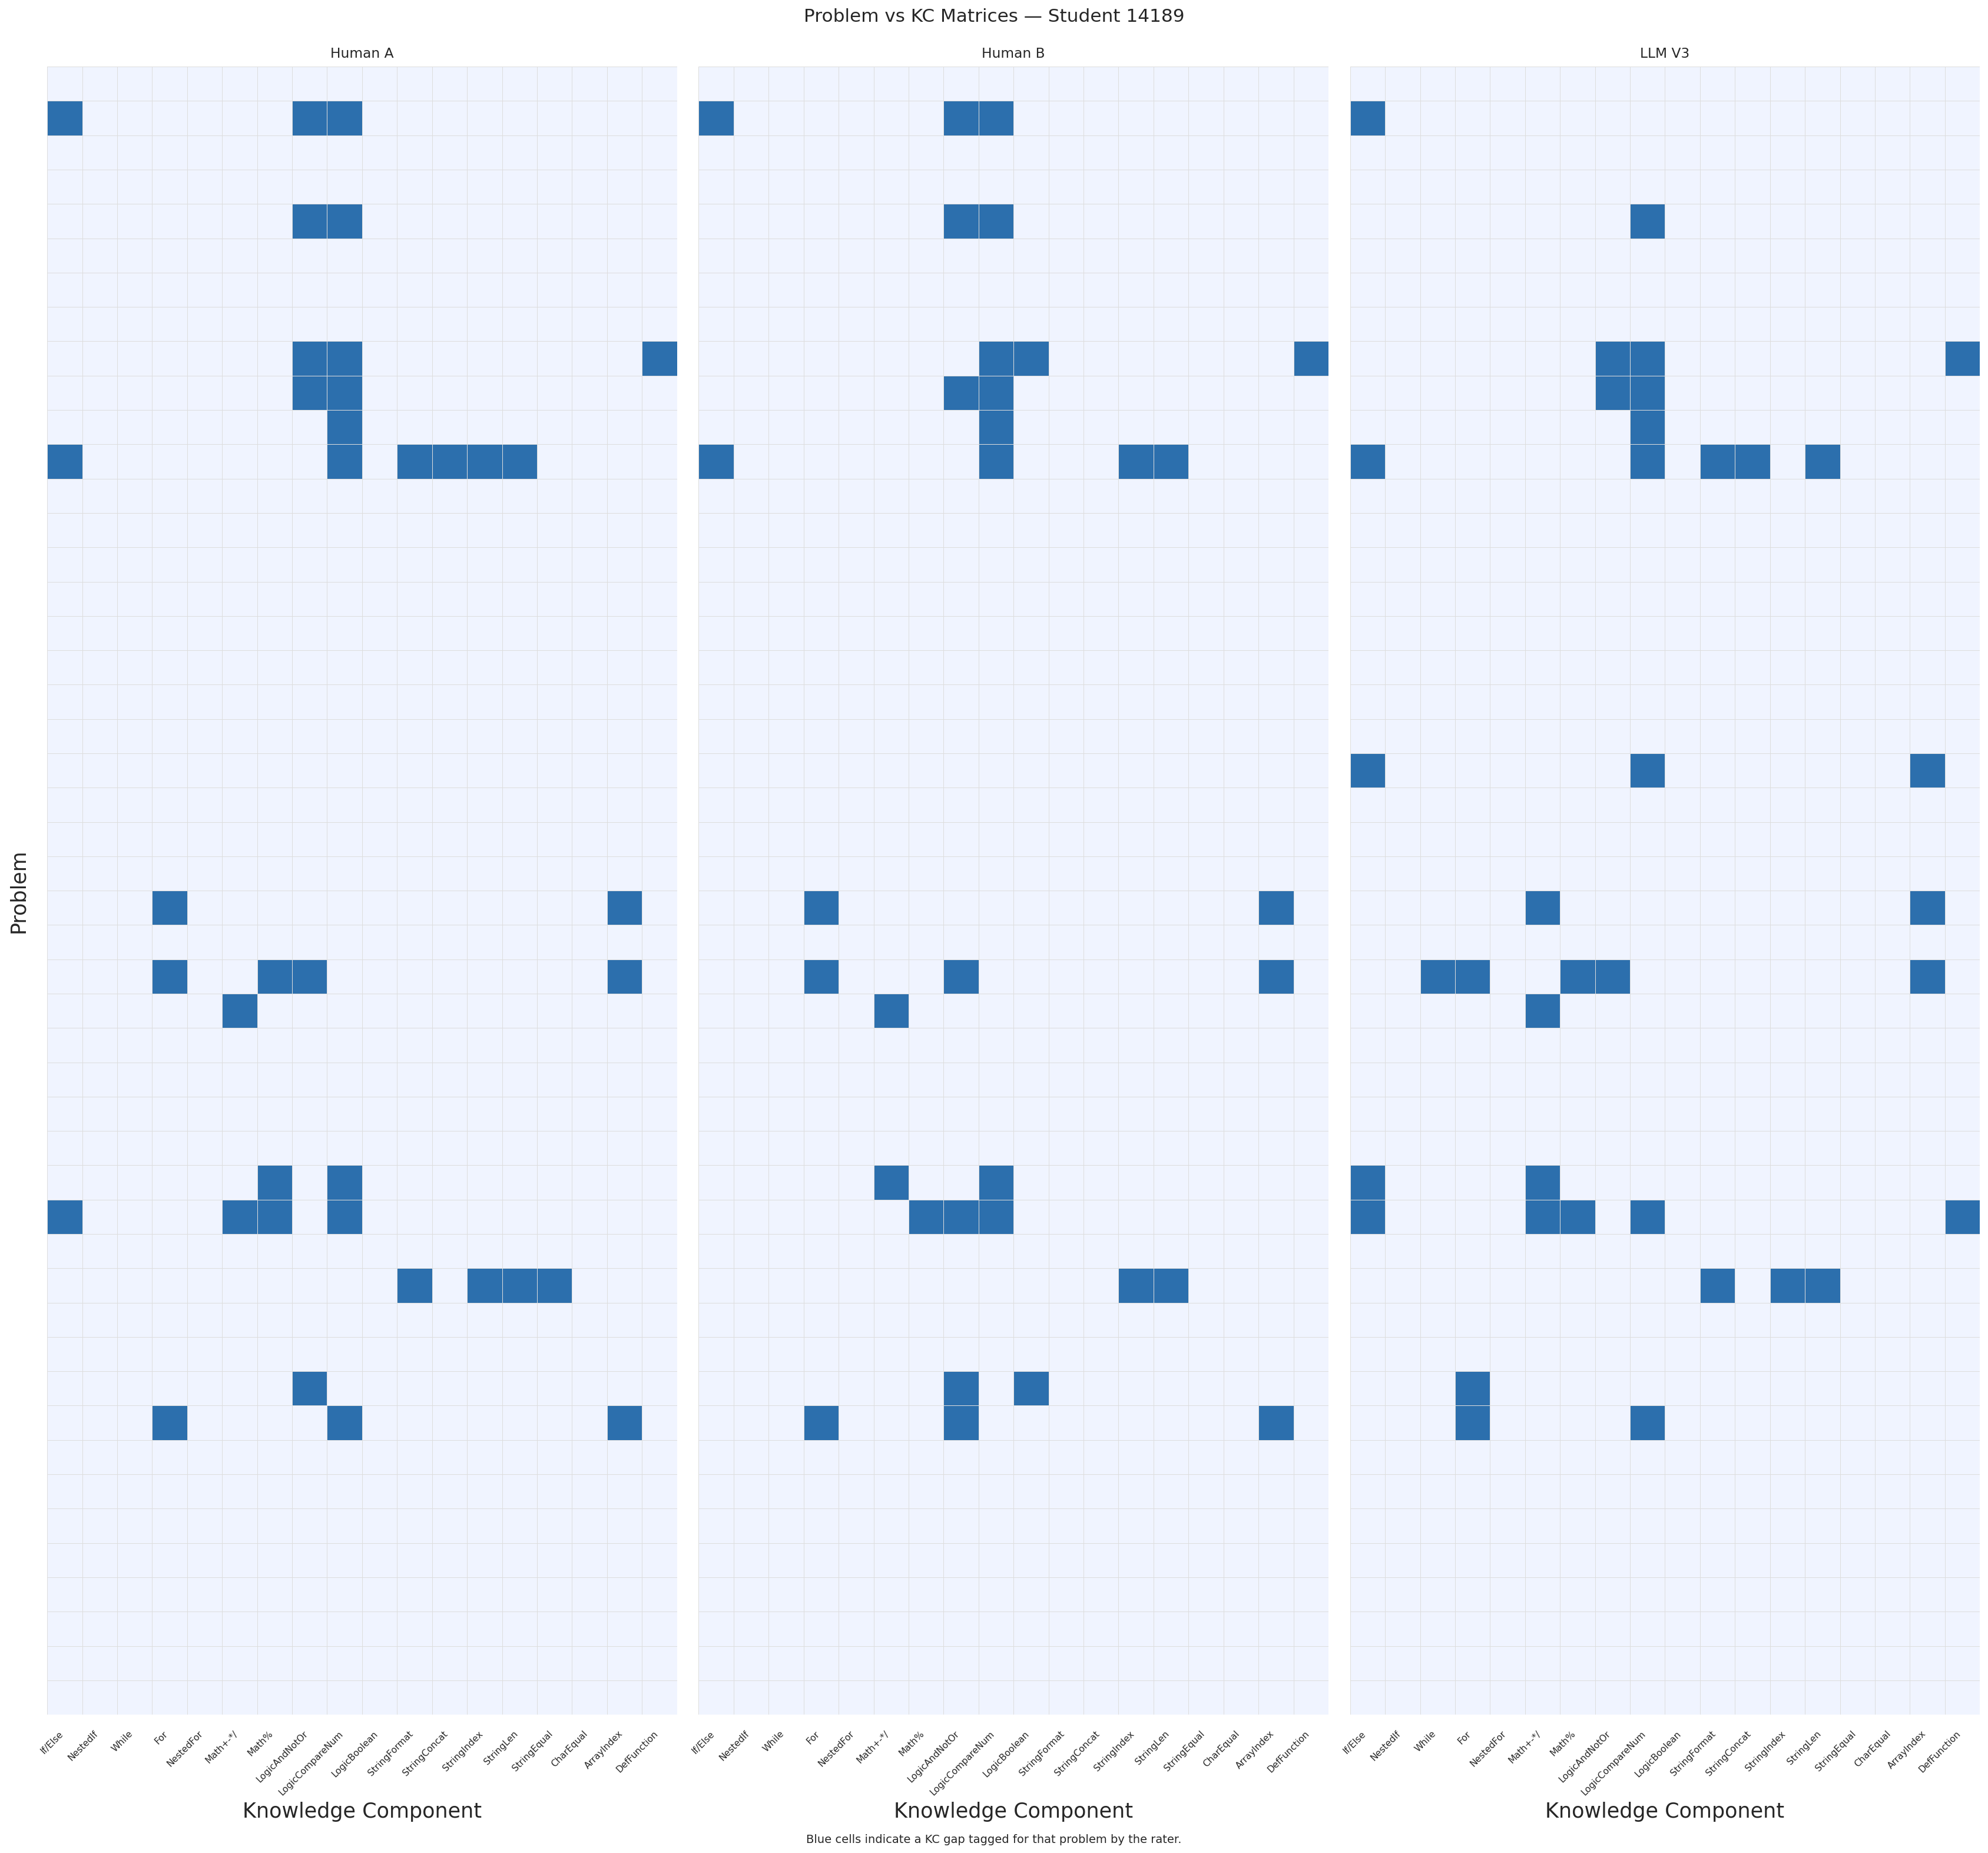

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/problem_kc_matrix_student_14189.png


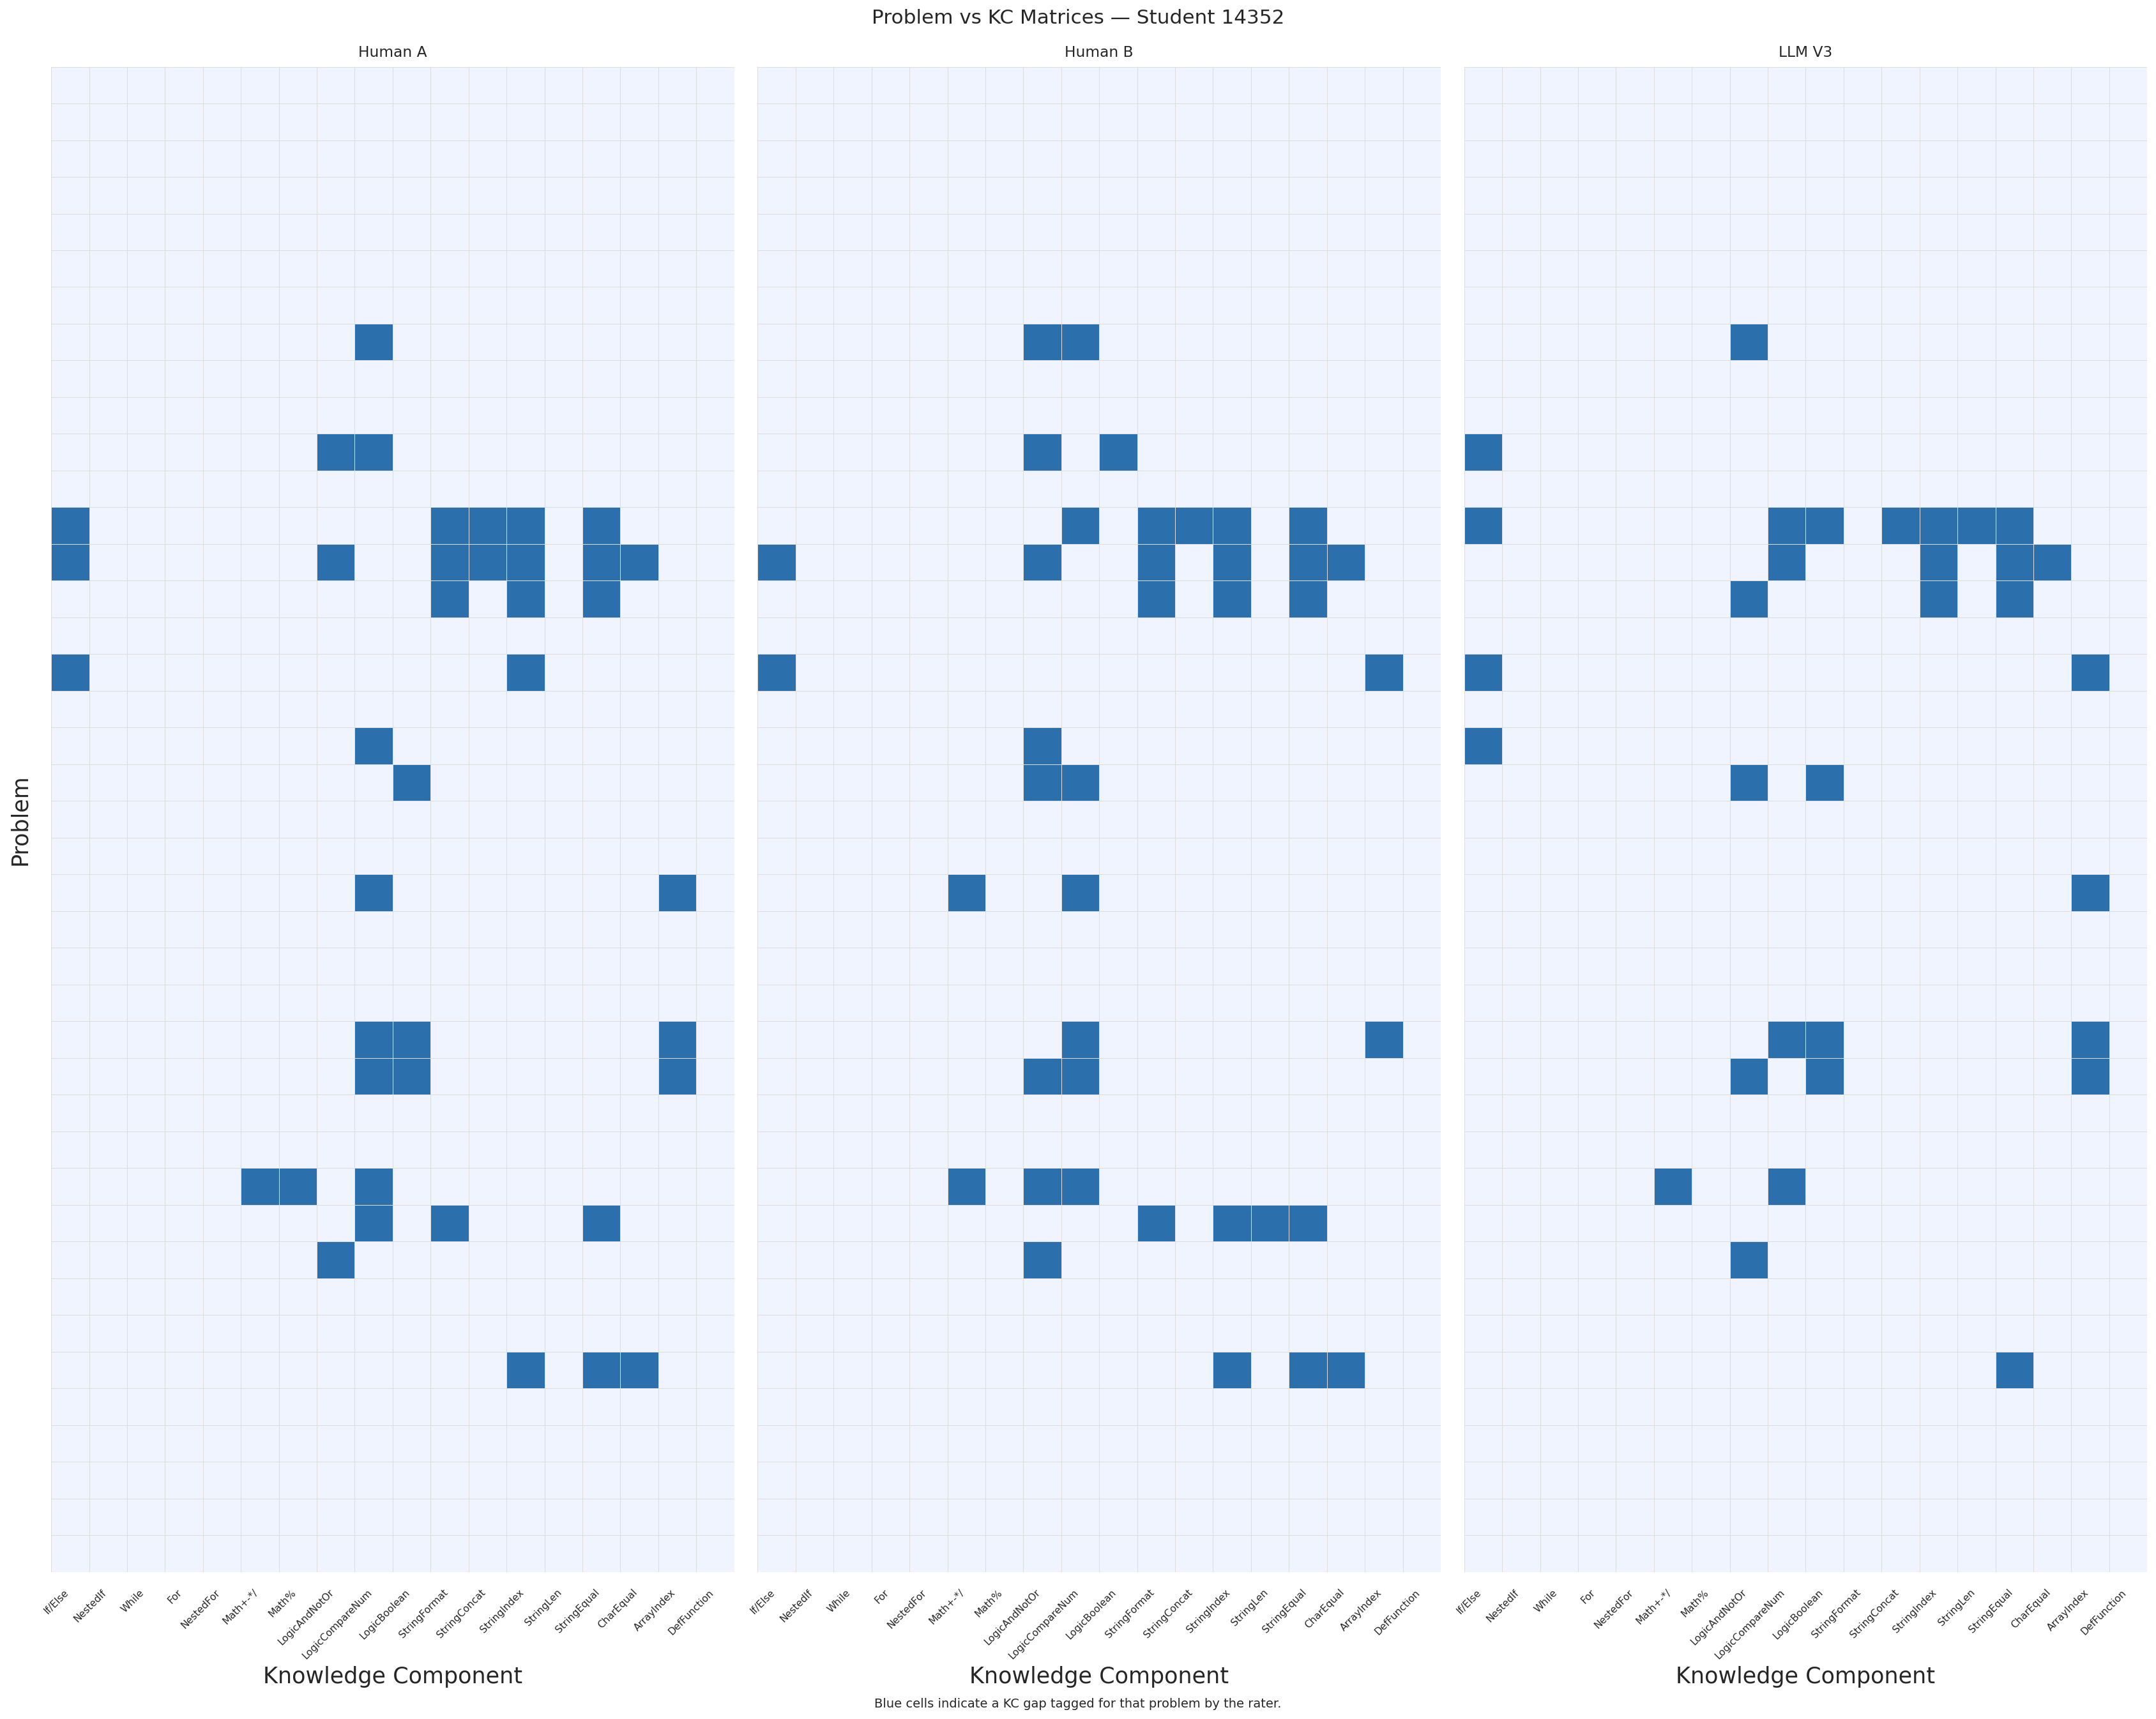

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/problem_kc_matrix_student_14352.png


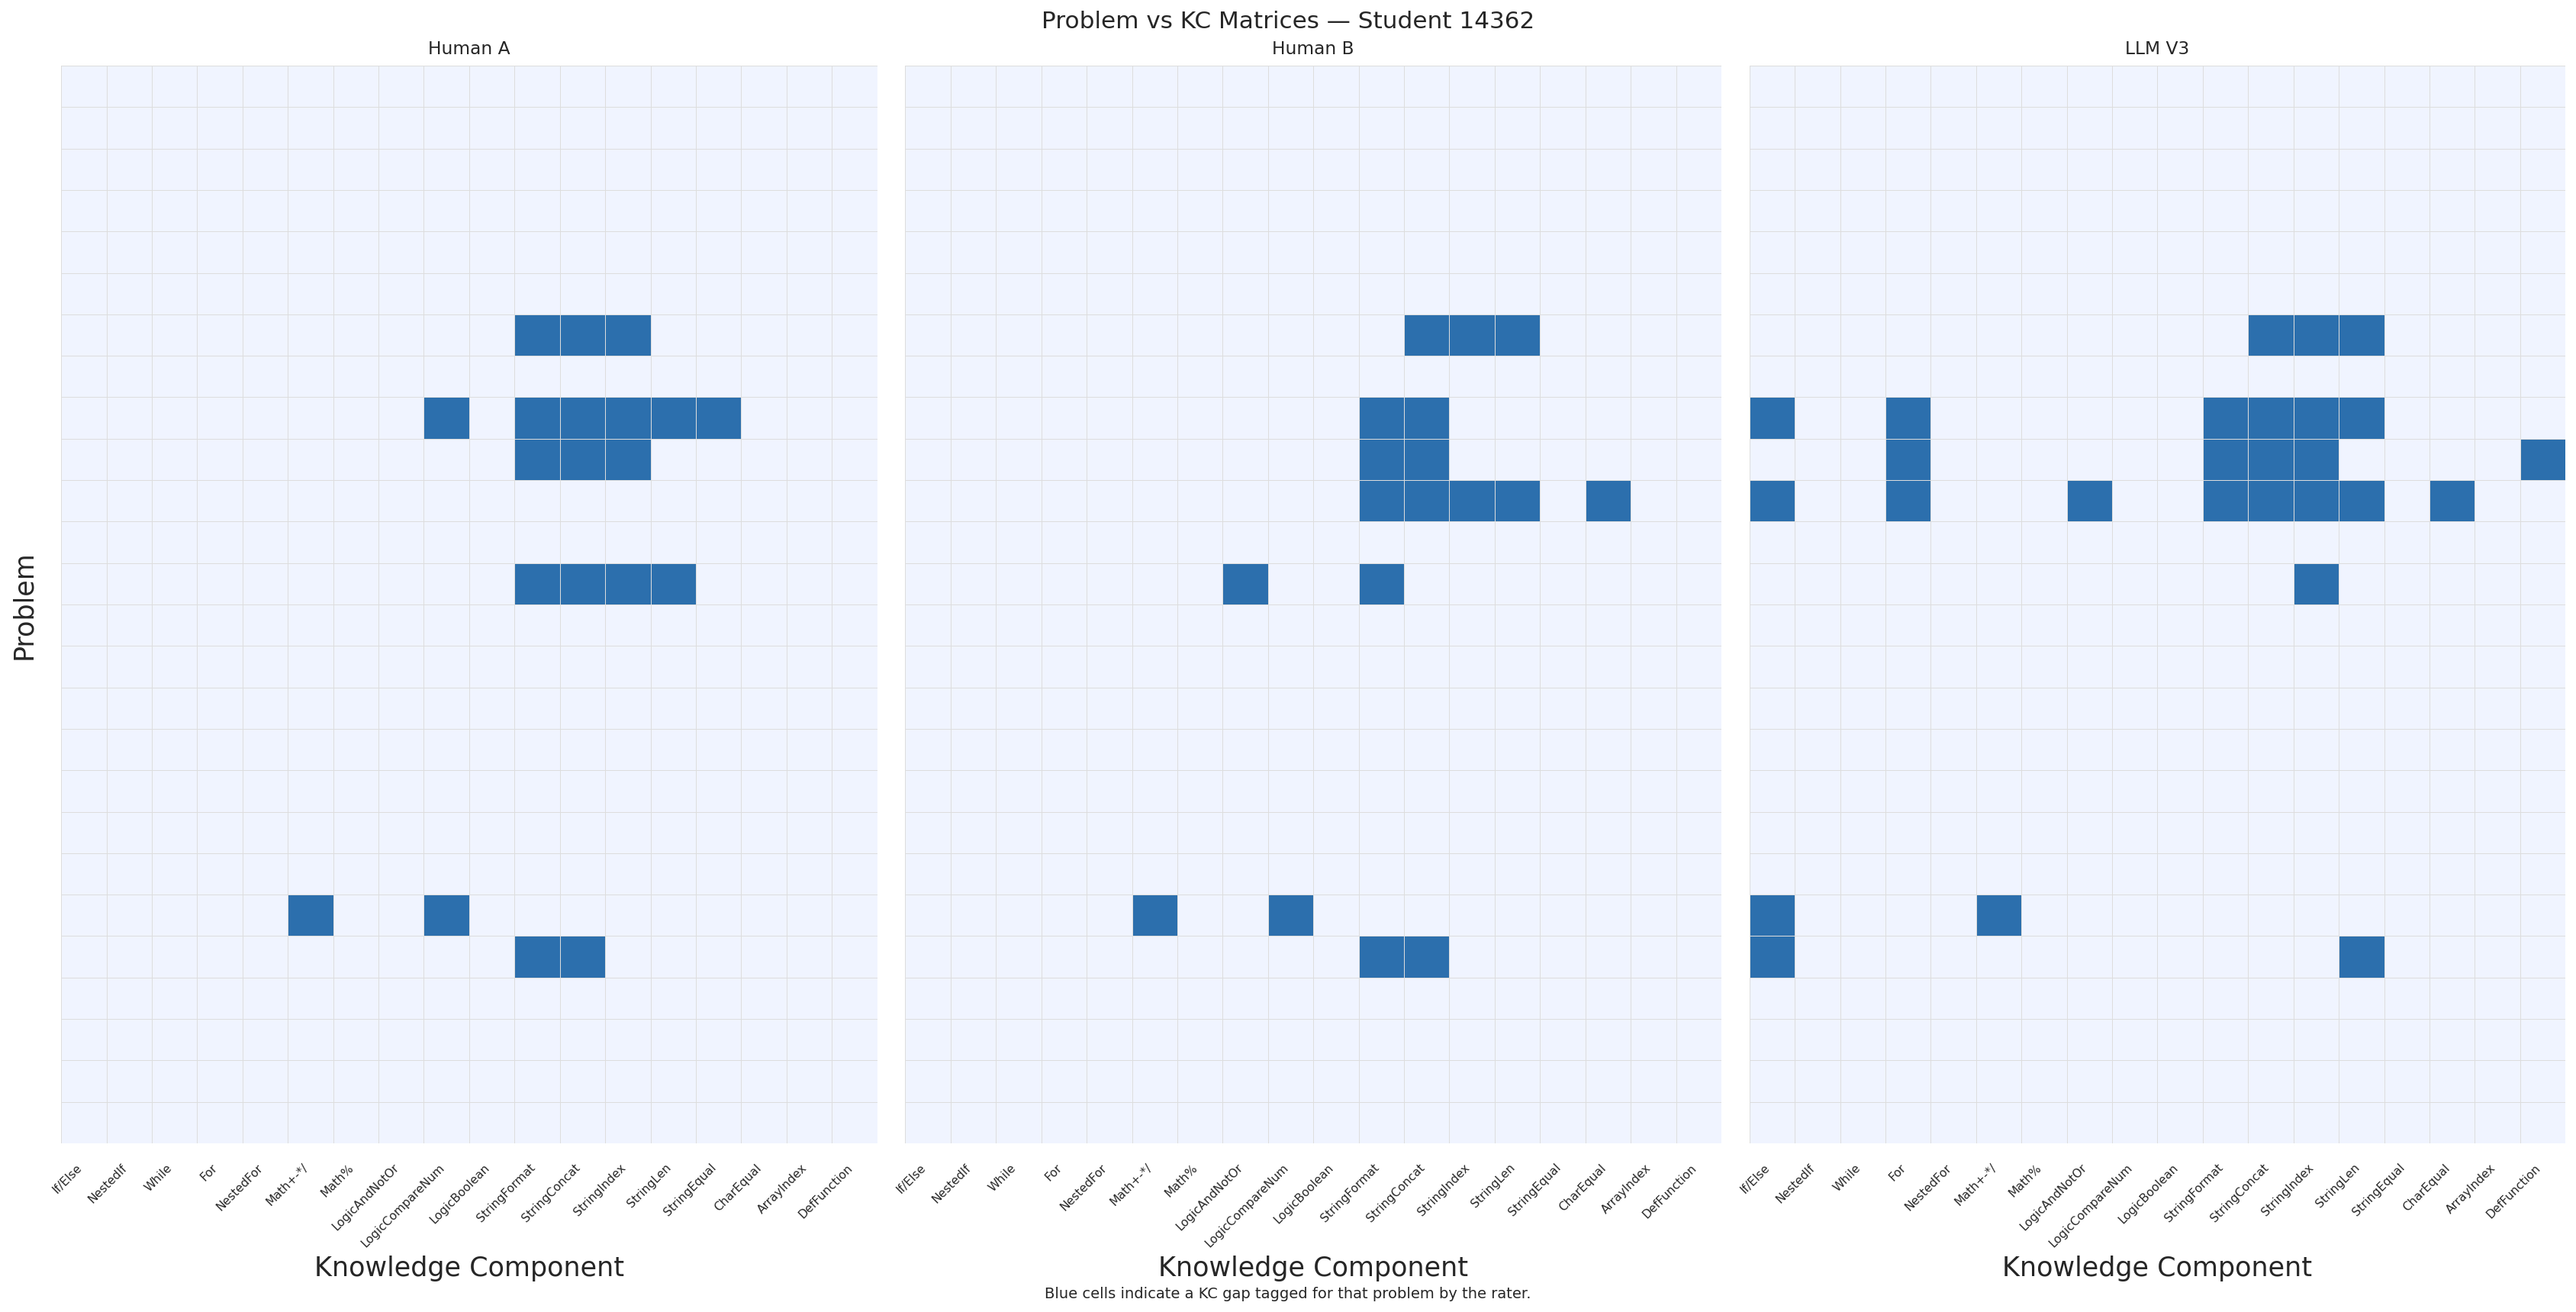

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/problem_kc_matrix_student_14362.png


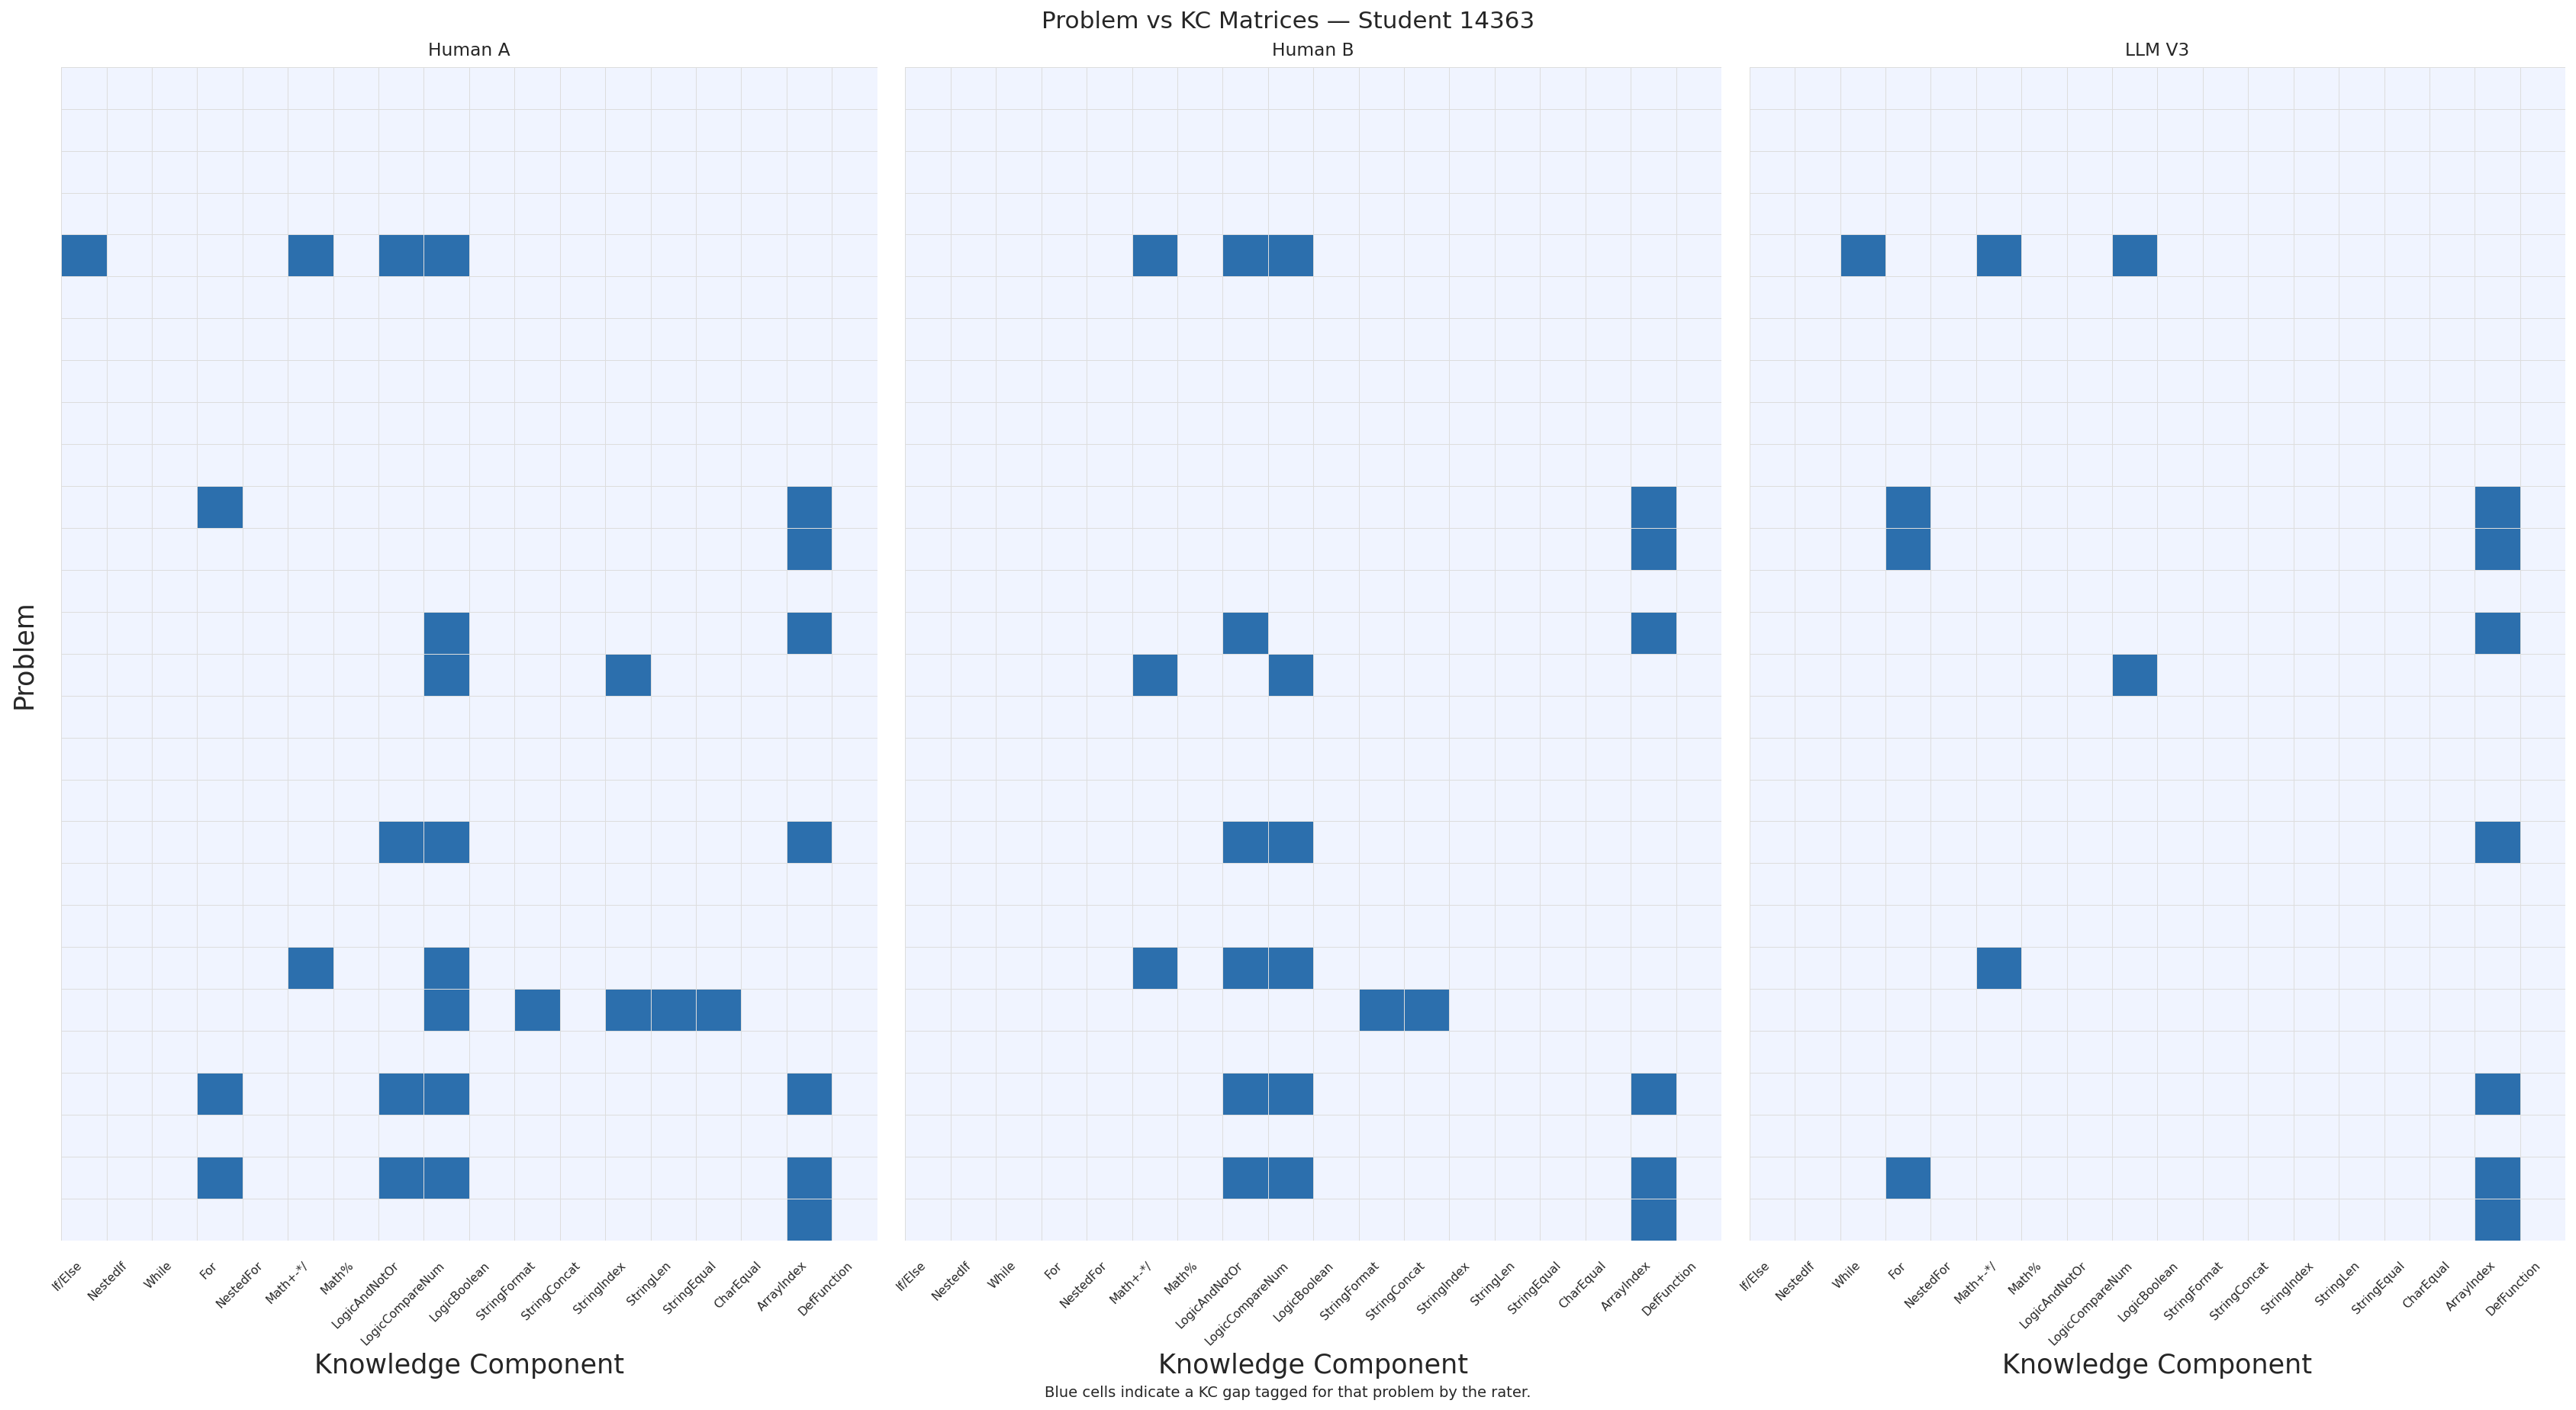

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/problem_kc_matrix_student_14363.png


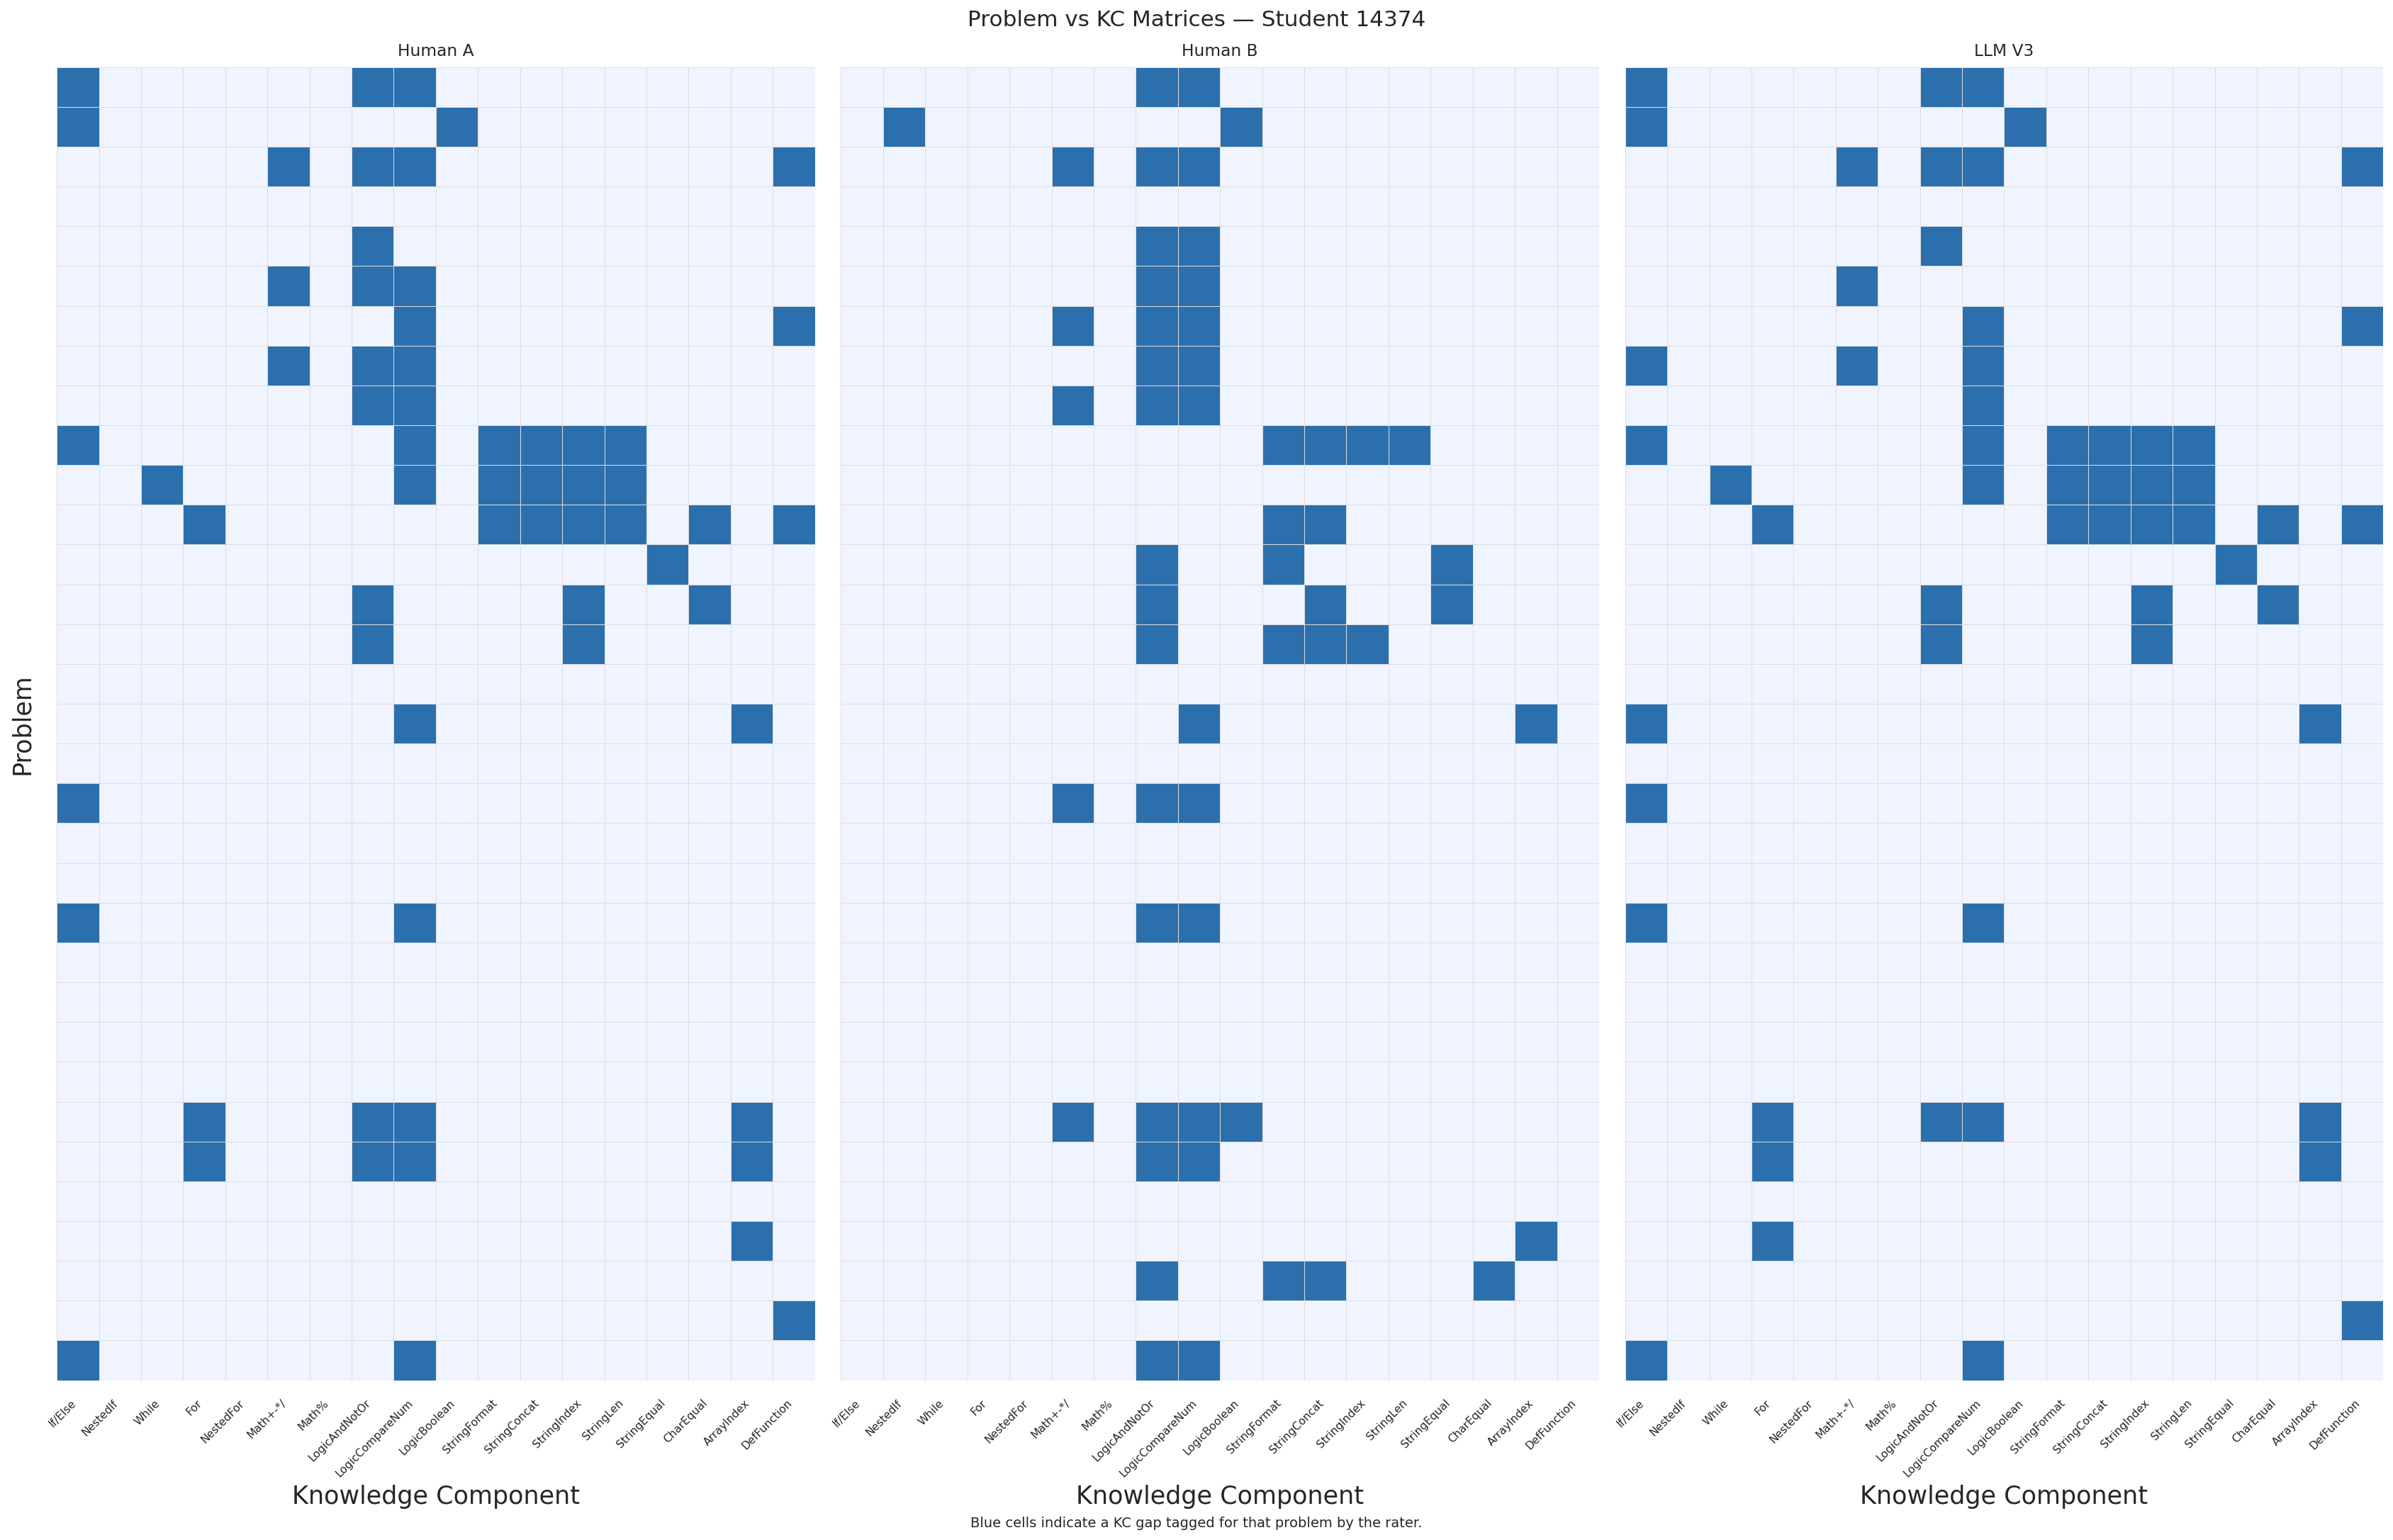

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/problem_kc_matrix_student_14374.png


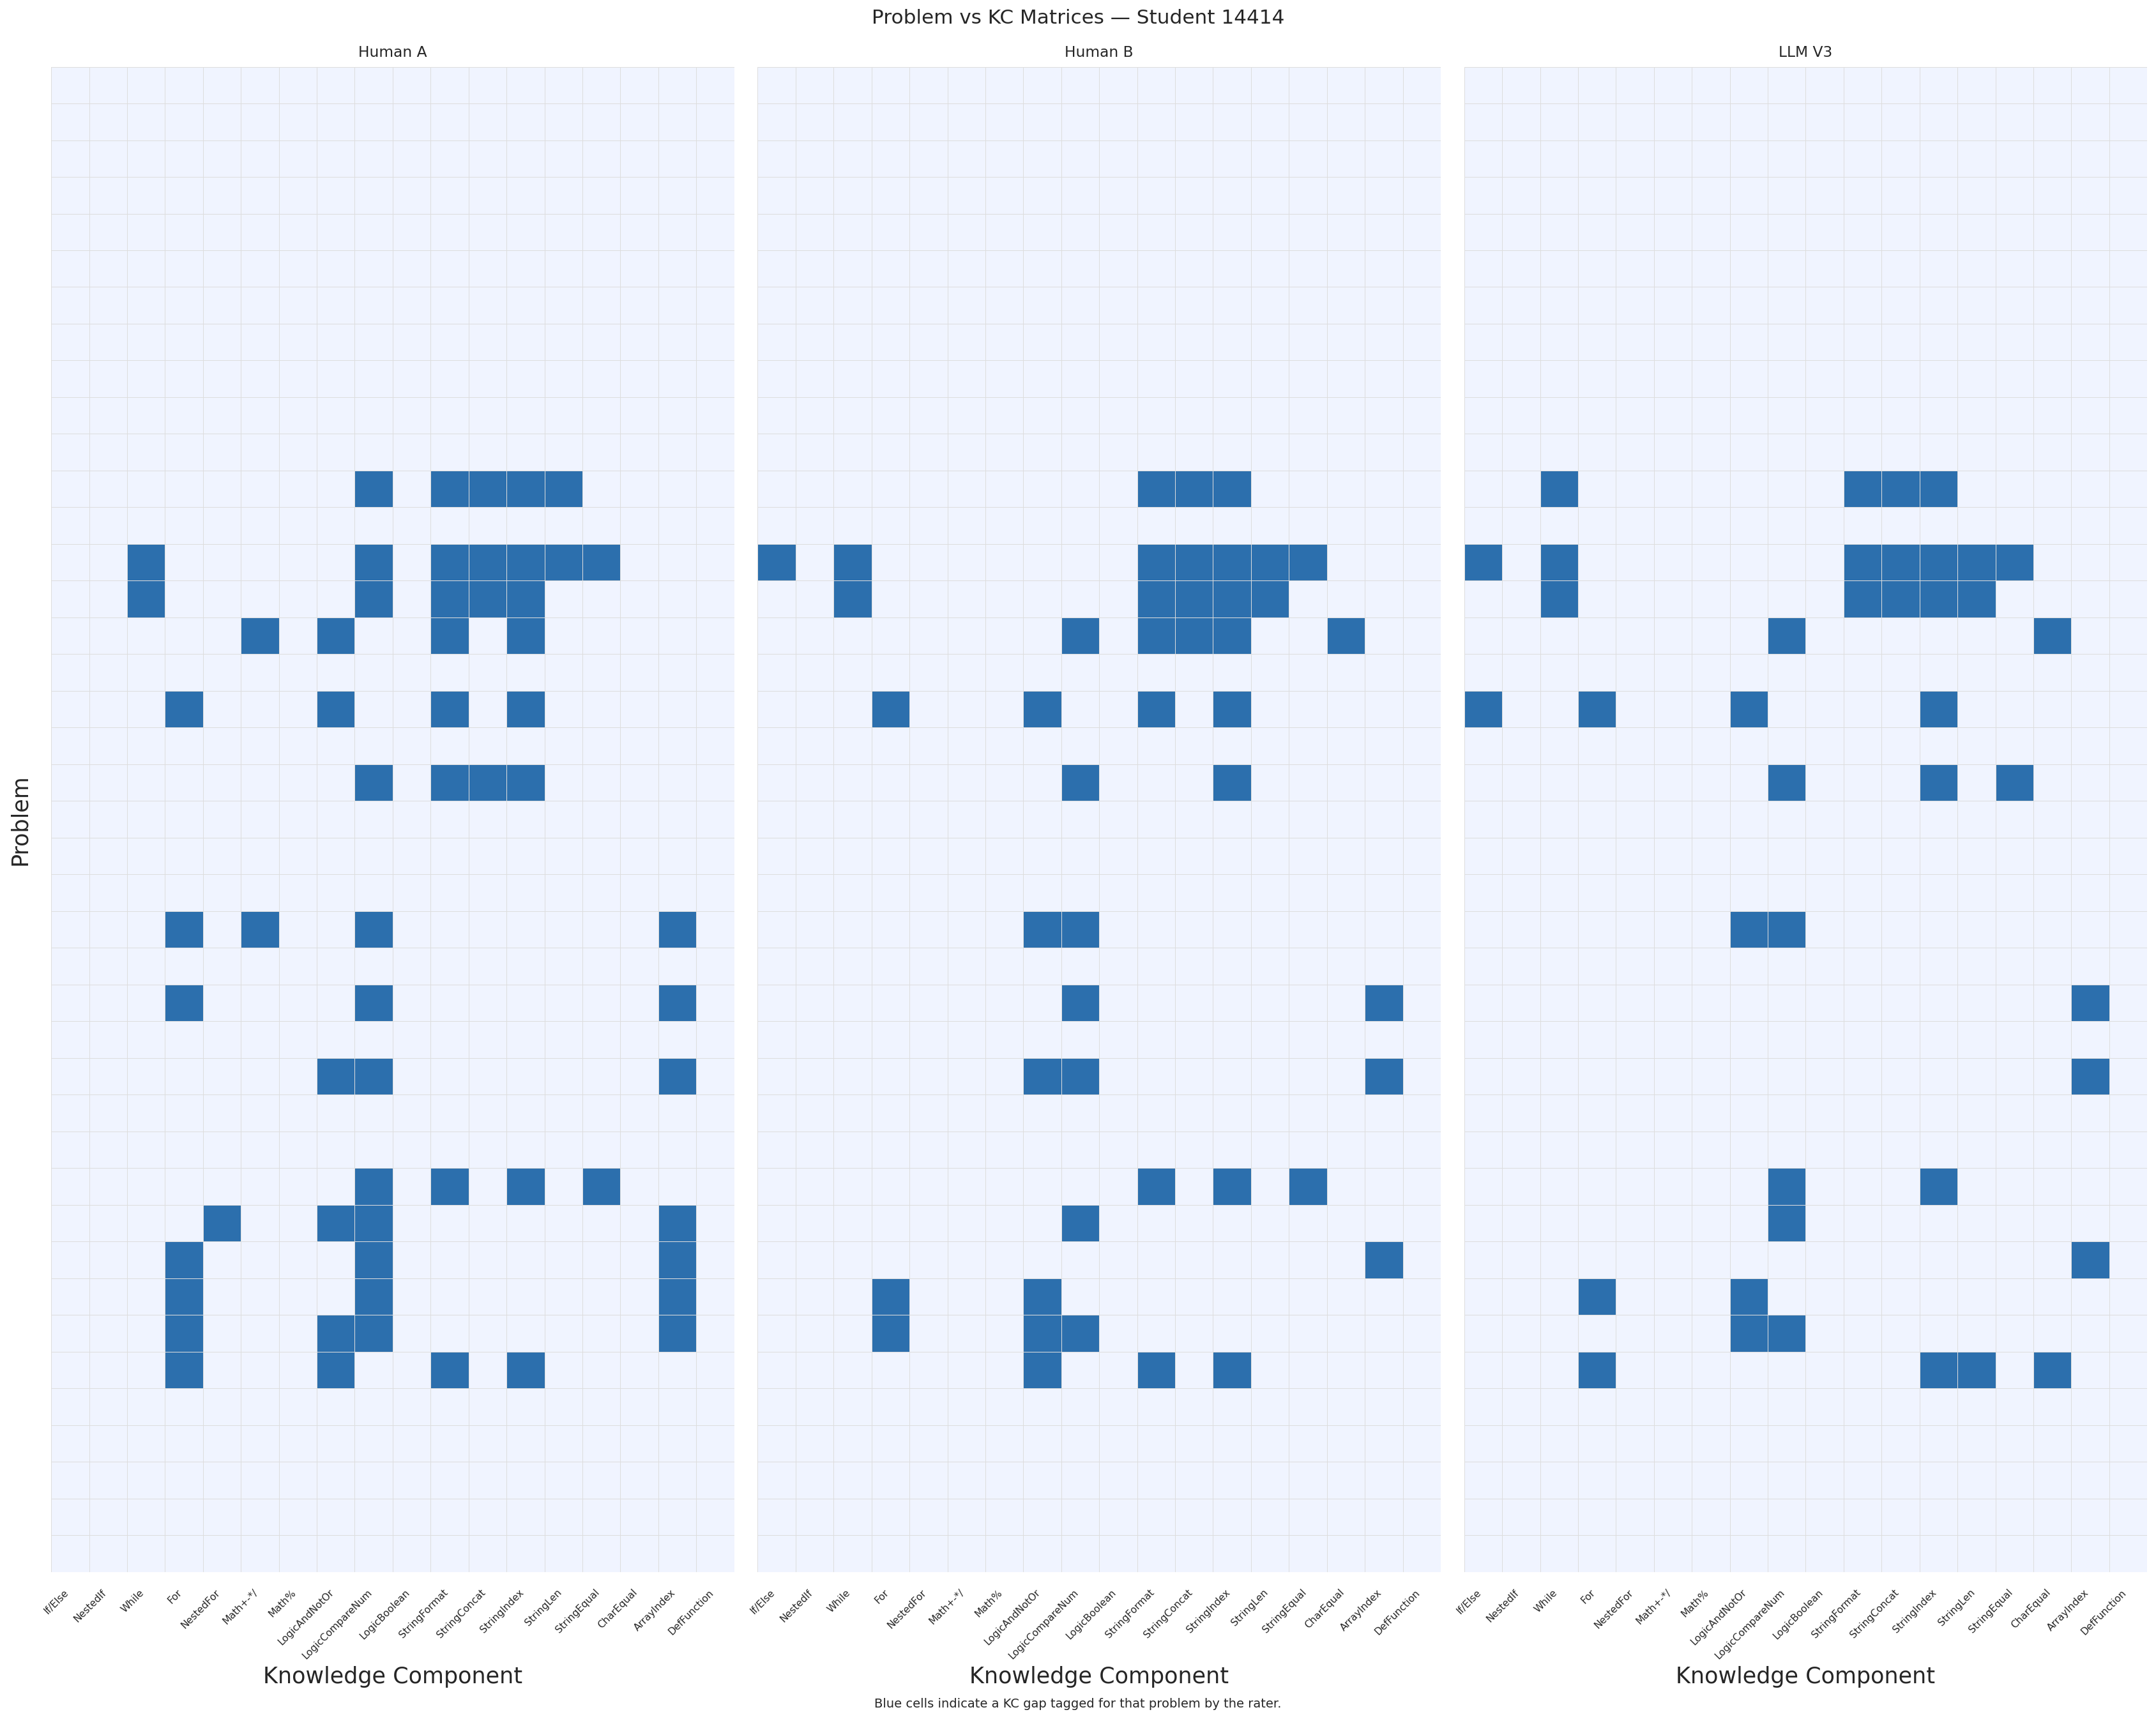

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/problem_kc_matrix_student_14414.png


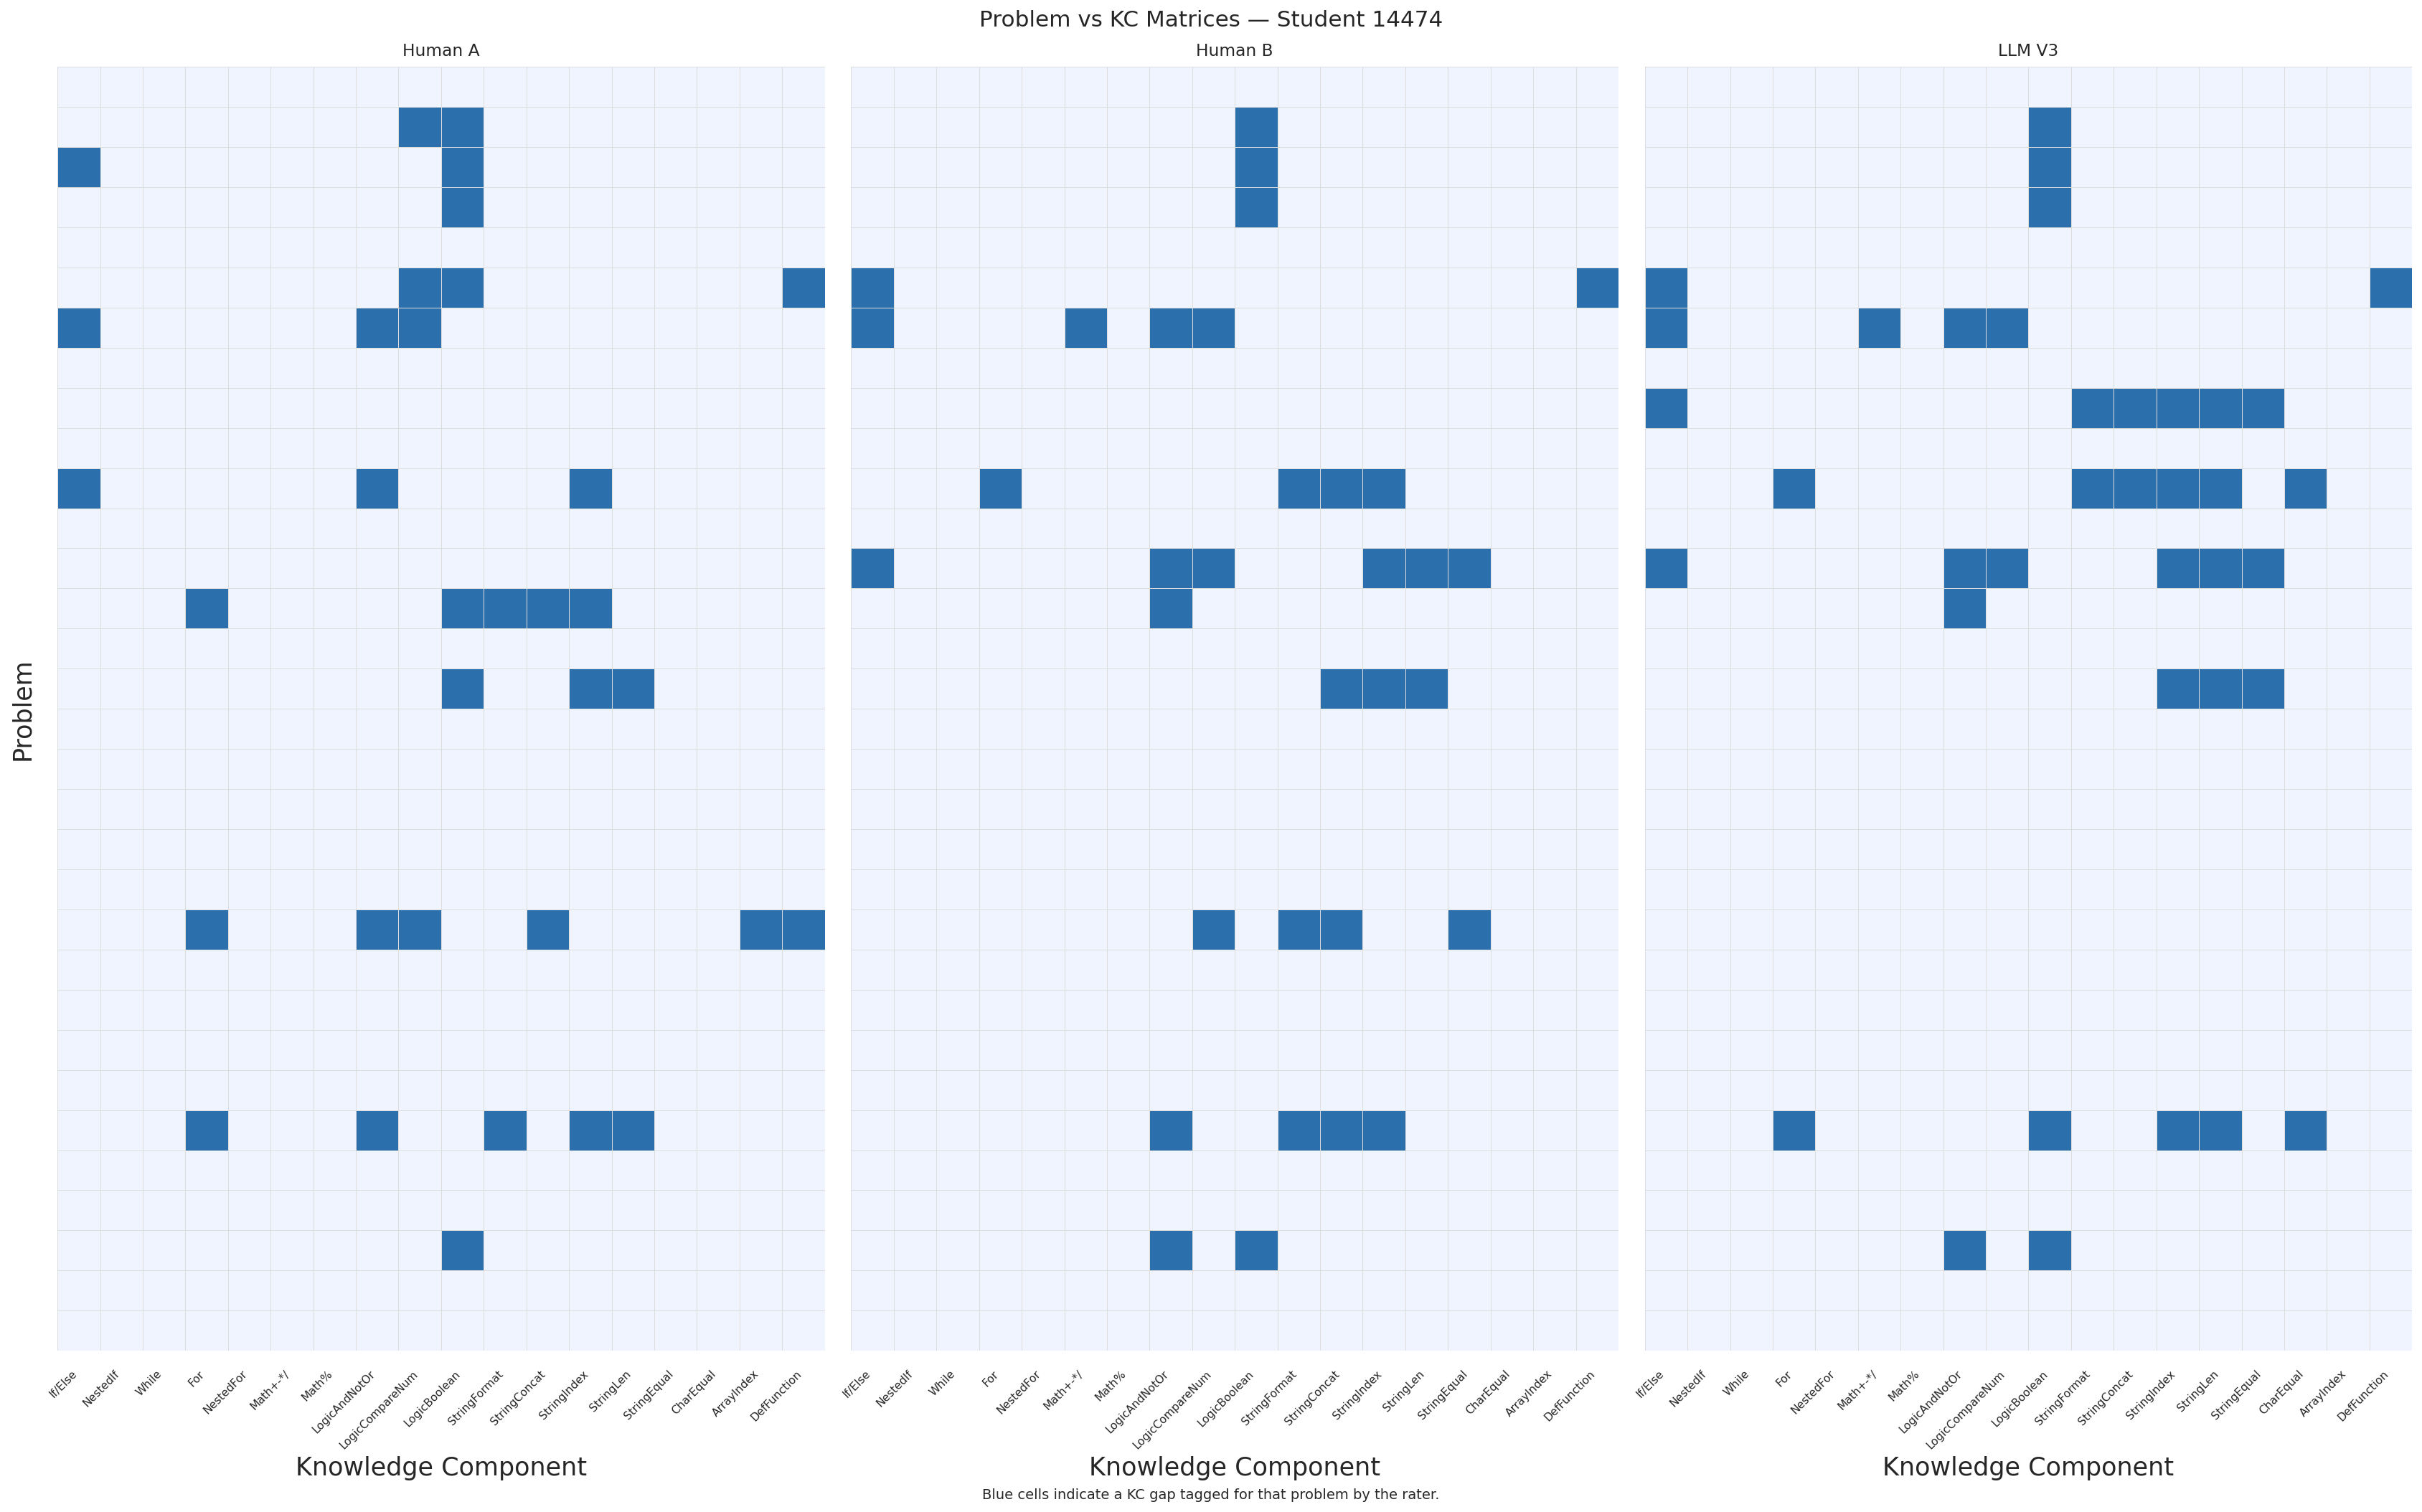

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/problem_kc_matrix_student_14474.png


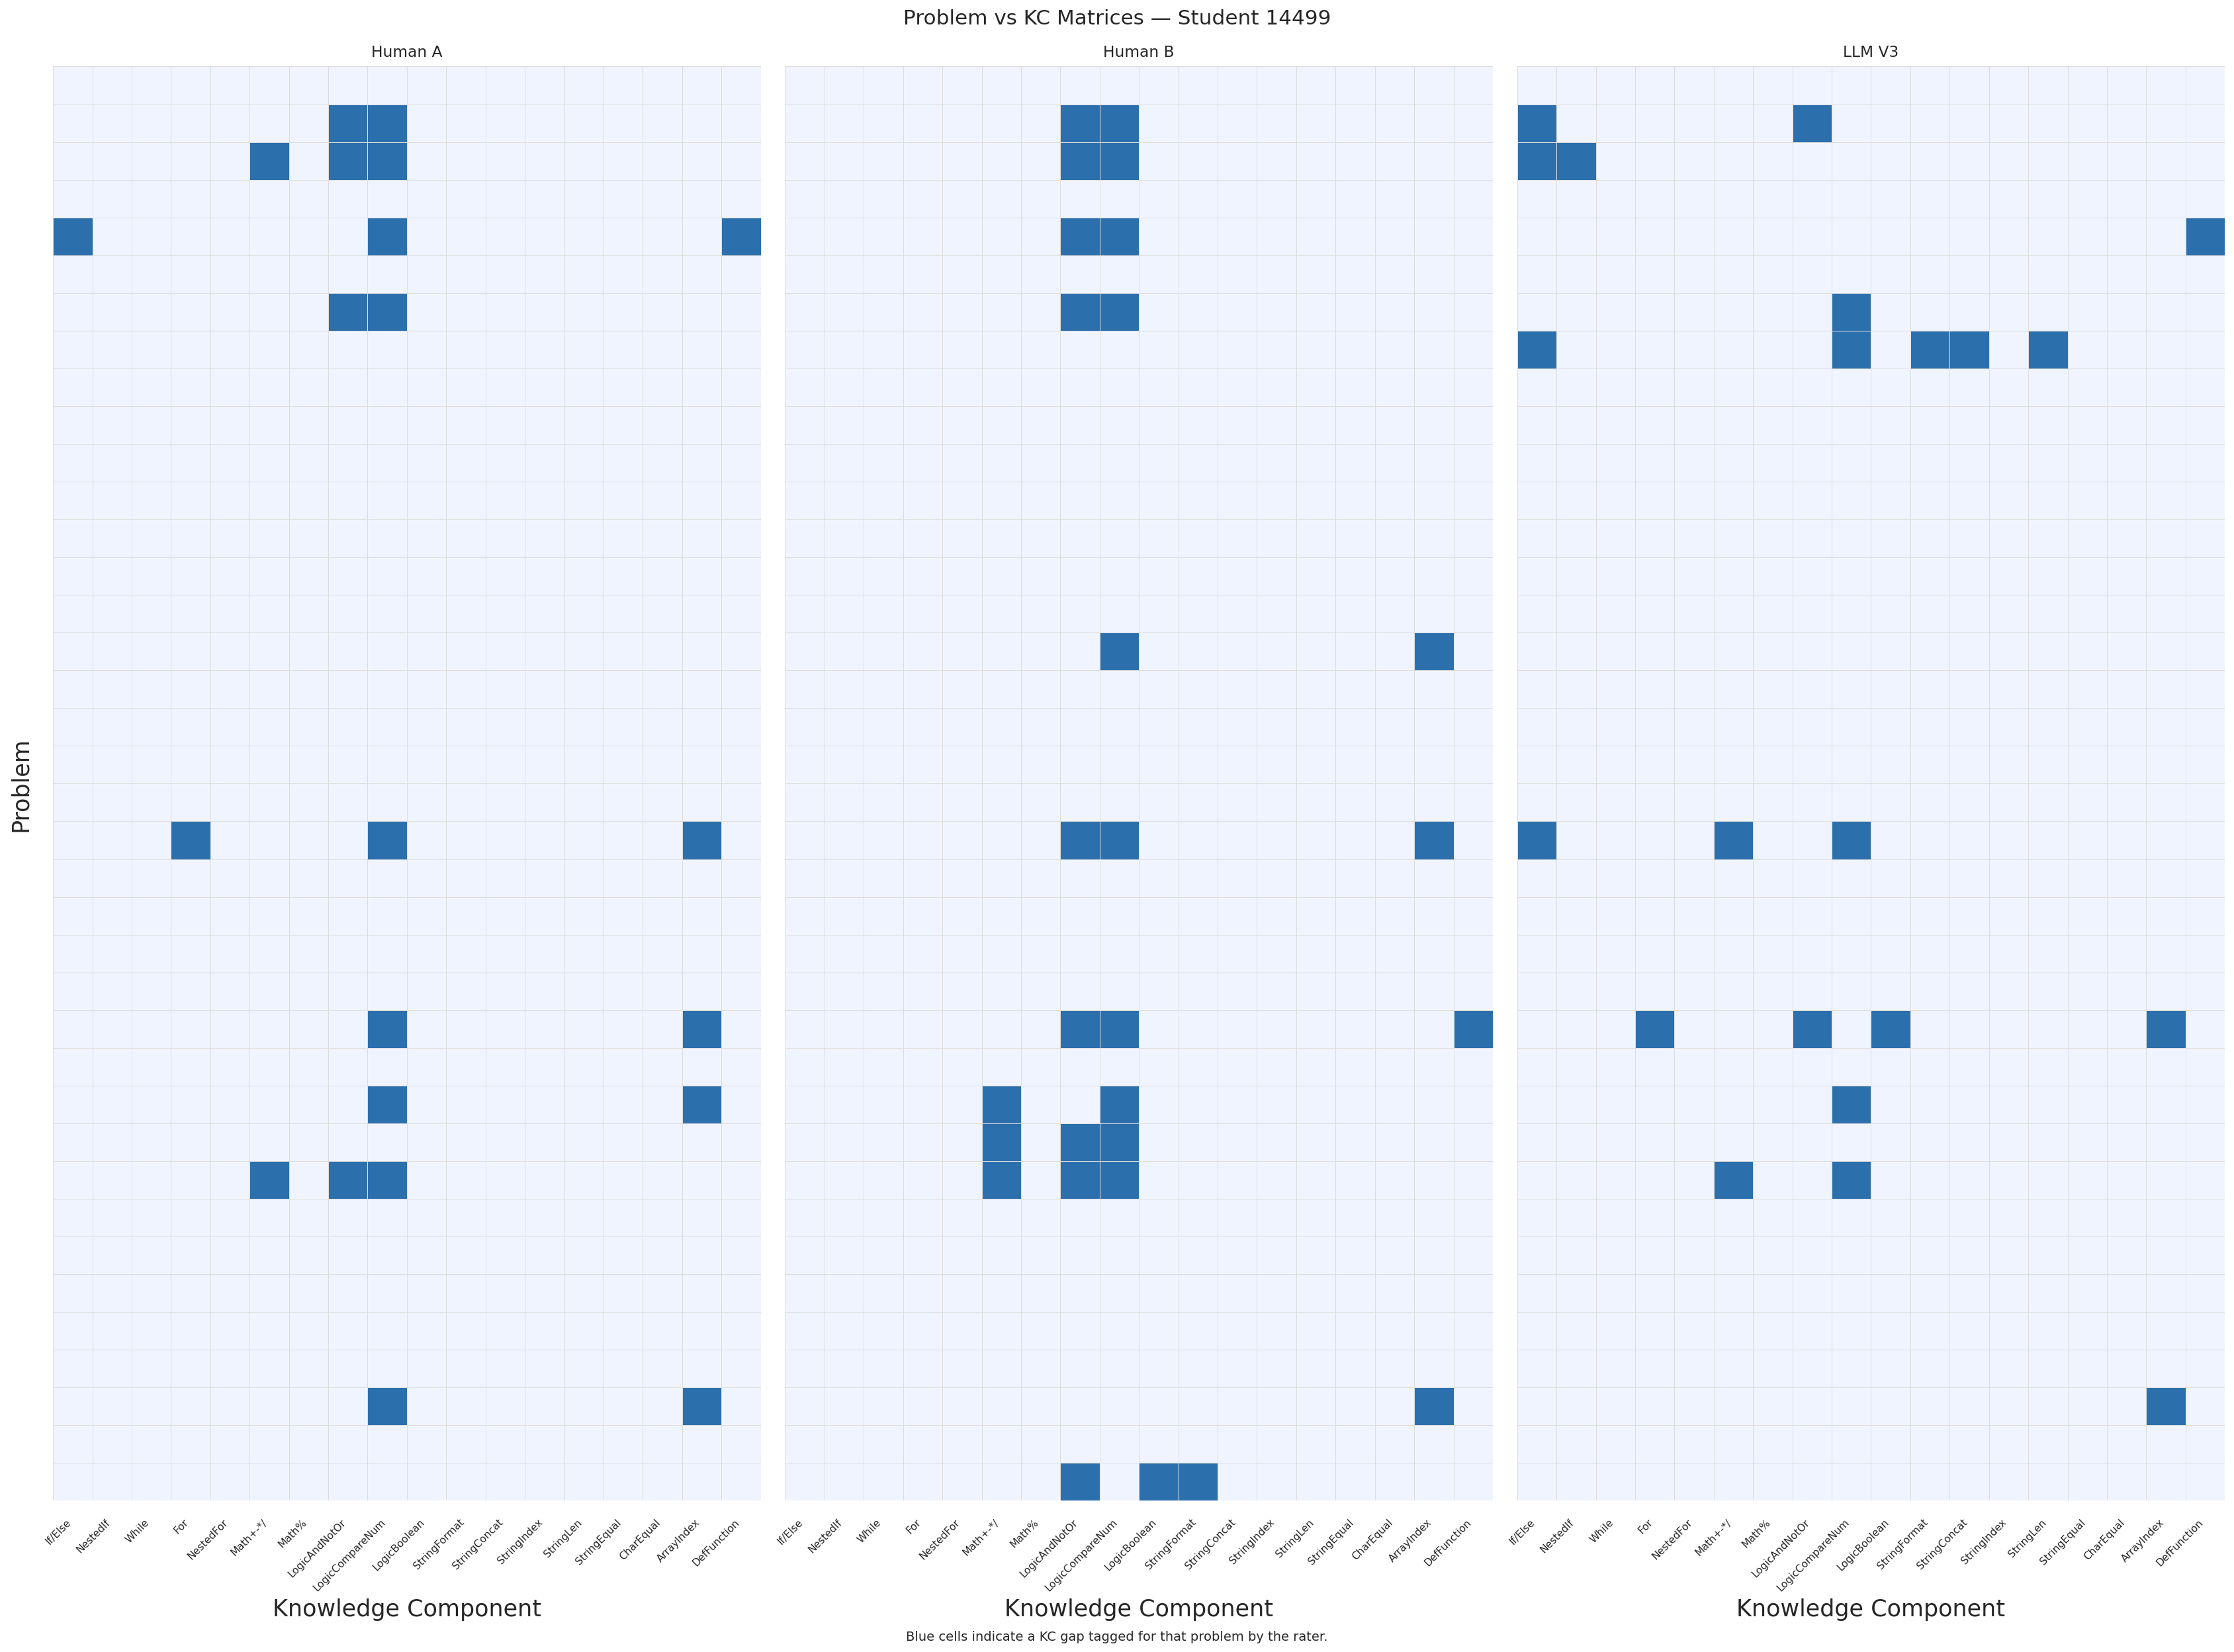

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp19_visualizations/problem_kc_matrix_student_14499.png


In [3]:
cmap = ListedColormap(['#f0f4ff', '#2c6fad'])

for student in students:
    student_pids = sorted(
        {pid for a in anns.values() for pid in a if pid.startswith(f'{student}_')},
        key=lambda p: int(p.split('_', 1)[1]),
    )
    if not student_pids:
        continue

    problem_labels = [f'P{pid.split("_", 1)[1]}' for pid in student_pids]

    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, max(8, len(student_pids) * 0.45)),
        sharey=True,
        constrained_layout=True,
    )

    for ax, (rater_name, ann) in zip(axes, anns.items()):
        matrix = np.zeros((len(student_pids), len(KC_COLUMNS)), dtype=int)
        for r, pid in enumerate(student_pids):
            for c, kc in enumerate(KC_COLUMNS):
                matrix[r, c] = 1 if kc in ann.get(pid, set()) else 0

        sns.heatmap(
            matrix,
            ax=ax,
            cmap=cmap,
            vmin=0, vmax=1,
            cbar=False,
            linewidths=0.35,
            linecolor='#dddddd',
            yticklabels=problem_labels,
            xticklabels=KC_COLUMNS,
        )
        ax.set_title(rater_name, fontsize=12, pad=8)
        ax.set_xlabel('Knowledge Component')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

    axes[0].set_ylabel('Problem')
    axes[1].set_ylabel('')
    axes[2].set_ylabel('')

    fig.suptitle(f'Problem vs KC Matrices — Student {student}', fontsize=16, y=1.02)
    fig.text(0.5, -0.01, 'Blue cells indicate a KC gap tagged for that problem by the rater.', ha='center', fontsize=10)

    out_path = FIG_DIR / f'problem_kc_matrix_student_{student}.png'
    fig.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f'Saved {out_path}')